# ML debiasing of the forecast toward ERA5-Land

**Goal.** Learn a correction that maps the served **IFS-HRES forecast** values
*onto the ERA5-Land archive scale*, so a recent/forecast day (served from HRES)
is comparable to the historical ERA5-Land climatology the percentiles are built
on. We debias **forecast → ERA5-Land** (ERA5-Land is the reference). Target is
`correction = era5 − hres`; `corrected = hres + correction`. The input level
feature is the **HRES value** — the thing we actually have at serving time.

**The pipeline lives in `train_quantile_debias.py`.** which is the single source of truth, and the notebook calls its functions — `preflight → load_and_verify → add_features → split →
shrink → fit_or_load → evaluate_variant`. The models under `models/` are the
**cached output of the full-grid VM run**: §7 *loads* them; only a cache miss (e.g. a custom `CELL_LIMIT`) would retrain.

**Four MultiQuantile fits per variable** (tmax, tmin, precip, wind) — quantiles
1/5/10/50/90/95/99 in one fit each, so **q50 is the point correction** and the
outer pairs give 90%/98% bands:

1. **M2_base** — geo + seasonal + fc_version features (no cell identity).
2. **M3_base** — M2_base + `key` as a native categorical.
3. **M2_cross** — M2_base + the other three `hres_*` values (regime features).
4. **M3_cross** — M3_base + the other three `hres_*` values.

**Data (cell-agnostic).** ERA5-Land truth from `data/archive-overlap/`, HRES
from `data/hres-forecast/`.

In [1]:
import gc, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The trainer script (same dir) owns the whole pipeline: paths, knobs, load,
# features, split, shrink, fit-or-load-from-cache and the headline evaluator.
# The notebook only orchestrates it and analyzes the results.
import train_quantile_debias as tqd
from train_quantile_debias import (VARS, QUANTILES, Q50, VARIANTS, SEED, MODELS,
                                   hres_col, feature_cols)

for var in VARS:                                   # prettier plot labels
    var['unit'] = {'degC': '°C'}.get(var['unit'], var['unit'])

def era5_col(var_name):
    return f"era5_{next(var['col'] for var in VARS if var['name'] == var_name)}"

# One shared palette — every plot below colors a given model the same way.
MODEL_COLORS = {'raw': '#bbb', 'M2_base': '#f4a259', 'M2_cross': '#5b8e7d',
                'M3_base': '#8d99ae', 'M3_cross': '#bc4b51'}
VARIANT_NAMES = [name for name in MODEL_COLORS if name != 'raw']   # plot order

# None = the FULL grid → TAG qn8727_s0 = what the VM trained, so §7 loads every
# fit from models/. An int = random cell sample for a quick experiment — its tag
# won't match the cache, so §7 would TRAIN all 16 fits on this machine.
CELL_LIMIT = None

cached_fits = sorted(path.name for path in MODELS.glob('*_qn8727_s0.cbm'))
print(f'models dir: {MODELS}')
print(f'{len(cached_fits)} cached full-grid fits, e.g. {cached_fits[:2]}')

models dir: /home/ita/HowHotWasIt/debias/models
16 cached full-grid fits, e.g. ['M2_base_precip_qn8727_s0.cbm', 'M2_base_tmax_qn8727_s0.cbm']


## 1. Preflight — cells.csv coverage, elevation, HRES files + ledger meta

`tqd.preflight` verifies every input the trainer needs — cells.csv,
cell_elevation.csv coverage, every cell's `hres_*.csv.gz` + resume-ledger meta
(the HRES cell center + elevation, which become features) — and returns the
static per-cell frame (elevation, distance-to-HRES-center, elevation delta).
It raises with the exact fix command if anything is missing or stale: the same
gate the VM run has to pass before training.

In [2]:
static = tqd.preflight(limit=CELL_LIMIT, allow_partial=False)
static.head()

[01:16:15] cells.csv: 8727 cells


[01:16:15] preflight OK: 8727 cells, elevation + HRES + ledger complete


,key,lat,lon,elevation,hres_lat,hres_lon,hres_elevation,dist_to_hres_km,elev_diff_m
0,23.8_90.4,23.8,90.4,11.4,23.796133,90.38055,12.0,2.025032,-0.6
1,22.6_88.4,22.6,88.4,4.6,22.601053,88.41122,11.0,1.157737,-6.4
2,24.9_67.0,24.9,67.0,19.5,24.920912,66.96774,20.0,3.998985,-0.5
3,13.0_77.6,13.0,77.6,907.7,12.970123,77.56364,928.0,5.153428,-20.3
4,30.1_31.3,30.1,31.3,48.9,30.125000,31.31250,18.0,3.028758,30.9


## 2. Load all four variables and join HRES↔ERA5-Land per day

`tqd.load_and_verify` reads every cell's archive slice + HRES file in parallel,
inner-joins them on date (keeping only the overlap window that has ERA5-Land
truth), applies prod's precip trace clamp (<1 mm → 0, as in tieredData.ts) and
errors if any cell's coverage is missing or stale. We deliberately skip the
script's step 2 (the `pull_archive_slice.py` refresh): the local `data/` dirs
mirror the exact slices the VM trained on, and refreshing could silently shift
the frame away from what the cached models saw.

In [3]:
df = tqd.load_and_verify(static, allow_partial=False)
df.head()

[01:18:24] loaded 8727 cells in 129s
[01:18:29] joined frame: 7,179,885 rows x 18 cols, 8727 cells, 2024-03-01..2026-06-01


,date,era5_tmax_C,era5_tmin_C,era5_precip_mm,era5_wind_max_ms,hres_tmax_C,hres_tmin_C,hres_precip_mm,hres_wind_max_ms,key,lat,lon,elevation,hres_lat,hres_lon,hres_elevation,dist_to_hres_km,elev_diff_m
0,2024-03-01,29.319000,15.725000,0.0,2.922,29.8,15.6,0.0,3.79,23.8_90.4,23.8,90.4,11.4,23.796133,90.38055,12.0,2.025032,-0.6
1,2024-03-02,29.694000,15.600000,0.0,2.394,30.1,15.2,0.0,3.44,23.8_90.4,23.8,90.4,11.4,23.796133,90.38055,12.0,2.025032,-0.6
2,2024-03-03,30.381001,19.256001,0.0,2.862,30.7,16.4,0.0,3.06,23.8_90.4,23.8,90.4,11.4,23.796133,90.38055,12.0,2.025032,-0.6
3,2024-03-04,28.319000,18.881001,0.0,2.309,29.4,18.9,1.5,3.55,23.8_90.4,23.8,90.4,11.4,23.796133,90.38055,12.0,2.025032,-0.6
4,2024-03-05,30.319000,20.850000,0.0,3.640,31.0,19.7,0.0,4.36,23.8_90.4,23.8,90.4,11.4,23.796133,90.38055,12.0,2.025032,-0.6


## 3. Shared features — seasonal phase + forecast-model version

`cos_doy`/`sin_doy` resolve the seasonal cycle (a lone cosine can't tell spring
from autumn). `fc_version` tags each day with the ECMWF IFS cycle Open-Meteo's
archive was on — a categorical feature so the model can absorb a
version-dependent offset (the changeover dates live at the top of
`train_quantile_debias.py`).

In [4]:
df = tqd.add_features(df)

[01:18:54] features: seasonal phase, fc_version ({'49r1': 4945773, '48r1': 2234112}), deciles (truth dec/dec1 + forecast fdec), bias targets


## 4. Per-variable target + decile labels — the tail bookkeeping

`tqd.add_features` also built, per variable and within every `cell × season`:

- the empirical percentile rank of the **ERA5-Land truth** value;
- decile label `dec`: `low` (driest/coldest/calmest 10%), `high` (top 10%), else `mid`;
- **1%-tail label `dec1`**: `p01` / `p99` — the genuine extremes, reported
  alongside the deciles so we can see whether the correction holds at 1-in-100
  days, not just 1-in-10;
- **forecast-decile `fdec`**: the same rank construction applied to the **HRES
  forecast** value. Unlike `dec`/`dec1` (truth-ranked → evaluation-only),
  `fdec` is known at prediction time, so §10 can legally *calibrate* on it
  (Mondrian CQR);
- target `bias = era5 − hres` (the additive correction to learn).

Rank-based (not z-score) is deliberate: precip/wind are skewed and
zero-inflated, so ranks put the genuine dry **and** wet (or cold **and** hot)
extremes in the tail buckets on both sides.

The pilot's extremity *training weights* are gone: the shipped models are
quantile regressions, and weighting rows by extremity would bias the estimated
quantiles (§12's rationale). The tails are handled by evaluating them
explicitly instead.

In [5]:
df[['key', 'date', 'season', 'fc_version', 'era5_tmax_C', 'hres_tmax_C',
    'bias_tmax', 'dec_tmax', 'dec1_tmax']].head()

,key,date,season,fc_version,era5_tmax_C,hres_tmax_C,bias_tmax,dec_tmax,dec1_tmax
0,23.8_90.4,2024-03-01,MAM,48r1,29.319000,29.8,-0.481000,mid,mid
1,23.8_90.4,2024-03-02,MAM,48r1,29.694000,30.1,-0.406000,mid,mid
2,23.8_90.4,2024-03-03,MAM,48r1,30.381001,30.7,-0.318999,mid,mid
3,23.8_90.4,2024-03-04,MAM,48r1,28.319000,29.4,-1.081000,low,mid
4,23.8_90.4,2024-03-05,MAM,48r1,30.319000,31.0,-0.681000,mid,mid


## 5. Split — blocked in time (all seasons in train, val & test)

A naïve "hold out the most-recent 20% of dates" is wrong for a **tail**
objective: the test set would cover only one season, so the hot tail (summer)
or cold tail (winter) could sit entirely in train and never be scored.
`tqd.split` blocks the timeline monthly and sends **every 5th whole block** to
test; whole blocks (not random rows) avoid adjacent-day leakage — a cell's
consecutive days share almost the same bias — and a 3-day **embargo** drops
train rows touching a held-out block. On top of the pilot's scheme it carves
**every 4th remaining block** out as a validation set: the VM fits early-stop
on it (`od_wait`), so test stays untouched during fitting. The season table
below confirms all four seasons appear in every split.

In [6]:
df = tqd.split(df)

[01:18:55] split: 28 blocks -> test 6, val 6 | rows train=3,735,156, val=1,579,587, test=1,597,041, embargo=268,101
role      train     val    test
season                         
DJF      733068  514893  270537
JJA      750522  270537  532347
MAM     1239234  532347  532347
SON     1012332  261810  261810


In [7]:
# THE SHRINK — not optional on this box. The full-grid frame is several GB of
# float64 + per-row str objects; float32 + categoricals is what let the trainer
# survive the VM's 16 GB (commit c99fad7a), and this machine has 16 GB too.
# It runs AFTER features + split, so none of the ranking/split math changes.
df = tqd.shrink(df)

[01:18:58] shrunk frame to 0.76 GiB (float32 + categoricals)


## 6. The evaluator

The models come from the trainer (§7 loads them); what stays notebook-side is
the decile-stratified `evaluate()` the plots use: apply a predicted correction
(clipped ≥0 for precip/wind), then report MAE **and** mean residual bias per
decile plus the 1% tails. Passing a zero prediction gives the **raw**
(do-nothing) baseline — the bar every model must beat. The script's own
`tqd.evaluate_variant` produces the headline + band-coverage numbers; §7 runs
both.

In [8]:
def evaluate(test, var_name, pred, nonneg):
    corrected = test[hres_col(var_name)].to_numpy() + np.asarray(pred)
    if nonneg:
        corrected = np.clip(corrected, 0, None)
    residual = test[era5_col(var_name)].to_numpy() - corrected
    decile = test[f'dec_{var_name}'].to_numpy()
    decile_mask = {'low': decile=='low', 'mid': decile=='mid', 'high': decile=='high'}
    mae  = {name: float(np.abs(residual[mask]).mean()) for name, mask in decile_mask.items()}
    bias = {name: float(residual[mask].mean())          for name, mask in decile_mask.items()}
    # 1% extreme tails (p01 = bottom 1%, p99 = top 1%) — same idea as the deciles
    tail_pctile = test[f'dec1_{var_name}'].to_numpy()
    for pctile_label, out_key in (('p01', 'low1'), ('p99', 'high1')):
        mask = tail_pctile == pctile_label
        mae[out_key]  = float(np.abs(residual[mask]).mean()) if mask.any() else float('nan')
        bias[out_key] = float(residual[mask].mean())          if mask.any() else float('nan')
    mae['all']   = float(np.abs(residual).mean())
    mae['tail']  = 0.5*(mae['low']  + mae['high'])    # headline: both 10% tails, equal
    mae['tail1'] = 0.5*(mae['low1'] + mae['high1'])   # both 1% tails, equal
    return {'mae': mae, 'bias': bias}

## 7. Load the 16 cached fits + evaluate

`tqd.fit_or_load` per variable × variant. With the full grid the tag is
`qn8727_s0`, so every fit loads from `models/` (the VM run's output) — nothing
trains. Each model predicts its 7 quantiles on the test rows **once**; we keep
only the small derived pieces —

- the script-style headline row (`tqd.evaluate_variant`: tail MAEs, band
  coverage/width, crossing rate),
- the notebook `evaluate()` decile summaries for the plots,
- the q50-corrected test values per variant (§9b reuses them),
- the full quantile matrix for `M3_cross` (§12 builds bands from it),
- feature importances,

— and free the model before loading the next one: sixteen CatBoost models at
once (the M3 fits alone are 300–440 MB *on disk*) would not fit in RAM next to
the frame.

In [9]:
RETRAIN = False    # True = refit even where a cached .cbm exists (Takes hours and a few GBs of RAM)
TAG = f'qn{df.key.nunique()}_s{SEED}'
print(f'tag: {TAG}')
LO90, HI90 = tqd.BANDS['90']   # q05/q95 column indices in the (n, 7) quantile matrix

results = {}         # results[var]['raw' | variant] = evaluate() decile summary
headline_rows = []   # script-style rows from tqd.evaluate_variant
q50_corrected = {}   # q50_corrected[var][variant] = corrected test values (float32)
band_preds = {}      # band_preds[var][variant] = sorted (n_test, 2) [q05, q95] float32
importances = {}     # importances[(var, variant)] = feature-importance Series
test_by_var = {}     # per-var test frame, reused by §9b/§12

start_time = time.time()
for var in VARS:
    var_name, nonneg = var['name'], var['nonneg']
    # slice to this var's columns BEFORE subsetting — same trick as the trainer:
    # four per-var copies of the full frame would dominate peak RAM
    keep_cols = list(dict.fromkeys(
        feature_cols(var_name, with_cell=True, with_cross=True)
        + [era5_col(var_name), f'bias_{var_name}', f'dec_{var_name}',
           f'dec1_{var_name}', f'fdec_{var_name}', 'date', 'season', 'role']))
    var_df = df.loc[df[f'bias_{var_name}'].notna(), keep_cols]
    train = var_df[var_df.role == 'train']
    val   = var_df[var_df.role == 'val']
    test  = var_df[var_df.role == 'test']
    print(f'== {var_name}: train {len(train):,} / val {len(val):,} / test {len(test):,} rows ==')

    results[var_name] = {'raw': evaluate(test, var_name, np.zeros(len(test)), nonneg)}
    q50_corrected[var_name] = {}
    for variant, (with_cell, with_cross) in VARIANTS.items():
        cols = feature_cols(var_name, with_cell, with_cross)
        cat_features = ['fc_version'] + (['key'] if with_cell else [])
        model, _ = tqd.fit_or_load(var_name, variant, train, val, cols,
                                   cat_features, tqd.MAX_ITERS, RETRAIN, TAG)
        quantile_preds = model.predict(test[cols])            # (n_test, 7)
        row, _ = tqd.evaluate_variant(test, var, quantile_preds)
        headline_rows.append({'var': var_name, 'variant': variant, **row})
        results[var_name][variant] = evaluate(test, var_name, quantile_preds[:, Q50], nonneg)
        importances[(var_name, variant)] = pd.Series(model.get_feature_importance(), index=cols)
        corrected = test[hres_col(var_name)].to_numpy() + quantile_preds[:, Q50]
        if nonneg:
            corrected = np.clip(corrected, 0, None)
        q50_corrected[var_name][variant] = corrected.astype(np.float32)
        band_sorted = np.sort(quantile_preds, axis=1)          # sort cols -> no crossing
        band_preds.setdefault(var_name, {})[variant] = band_sorted[:, [LO90, HI90]].astype(np.float32)
        del model, quantile_preds, corrected, band_sorted
        gc.collect()                    # the big M3 fits must not stack up
    test_by_var[var_name] = test
    del var_df, train, val
    gc.collect()

headline = pd.DataFrame(headline_rows)
column_order = ['var', 'variant', 'raw_tailMAE', 'tailMAE', 'tail_impr_%',
                'raw_tail1MAE', 'tail1MAE', 'tail1_impr_%', 'raw_MAE', 'MAE',
                'all_impr_%', 'cov90', 'width90', 'cov90_tails', 'cov98',
                'width98', 'cov98_tails', 'crossing_%']
print(f'\n4 vars x 4 variants in {(time.time() - start_time)/60:.1f} min  (RETRAIN={RETRAIN})')
print('\n== headline: q50 as point correction; coverage on the bias target ==')
print(headline[column_order].round(3).to_string(index=False))

tag: qn8727_s0
== tmax: train 3,735,156 / val 1,579,587 / test 1,597,041 rows ==
[01:18:59]   M2_base_tmax: loaded cache (M2_base_tmax_qn8727_s0.cbm)
[01:19:02]   M3_base_tmax: loaded cache (M3_base_tmax_qn8727_s0.cbm)
[01:19:09]   M2_cross_tmax: loaded cache (M2_cross_tmax_qn8727_s0.cbm)
[01:19:13]   M3_cross_tmax: loaded cache (M3_cross_tmax_qn8727_s0.cbm)
== tmin: train 3,735,156 / val 1,579,587 / test 1,597,041 rows ==
[01:19:20]   M2_base_tmin: loaded cache (M2_base_tmin_qn8727_s0.cbm)
[01:19:23]   M3_base_tmin: loaded cache (M3_base_tmin_qn8727_s0.cbm)
[01:19:29]   M2_cross_tmin: loaded cache (M2_cross_tmin_qn8727_s0.cbm)
[01:19:33]   M3_cross_tmin: loaded cache (M3_cross_tmin_qn8727_s0.cbm)
== precip: train 3,735,156 / val 1,579,587 / test 1,597,041 rows ==
[01:19:40]   M2_base_precip: loaded cache (M2_base_precip_qn8727_s0.cbm)
[01:19:43]   M3_base_precip: loaded cache (M3_base_precip_qn8727_s0.cbm)
[01:19:46]   M2_cross_precip: loaded cache (M2_cross_precip_qn8727_s0.cbm)
[01:

## 8. Plots — does the correction help and specifically **at the tails**?

Left: MAE in the low / mid / high decile, raw vs each variant's q50 correction
— the bars over `low` and `high` are what we care about most. Right: mean
residual **bias** per decile for the same five models; flat-at-zero across all
three buckets = well-calibrated in both tails and the center.

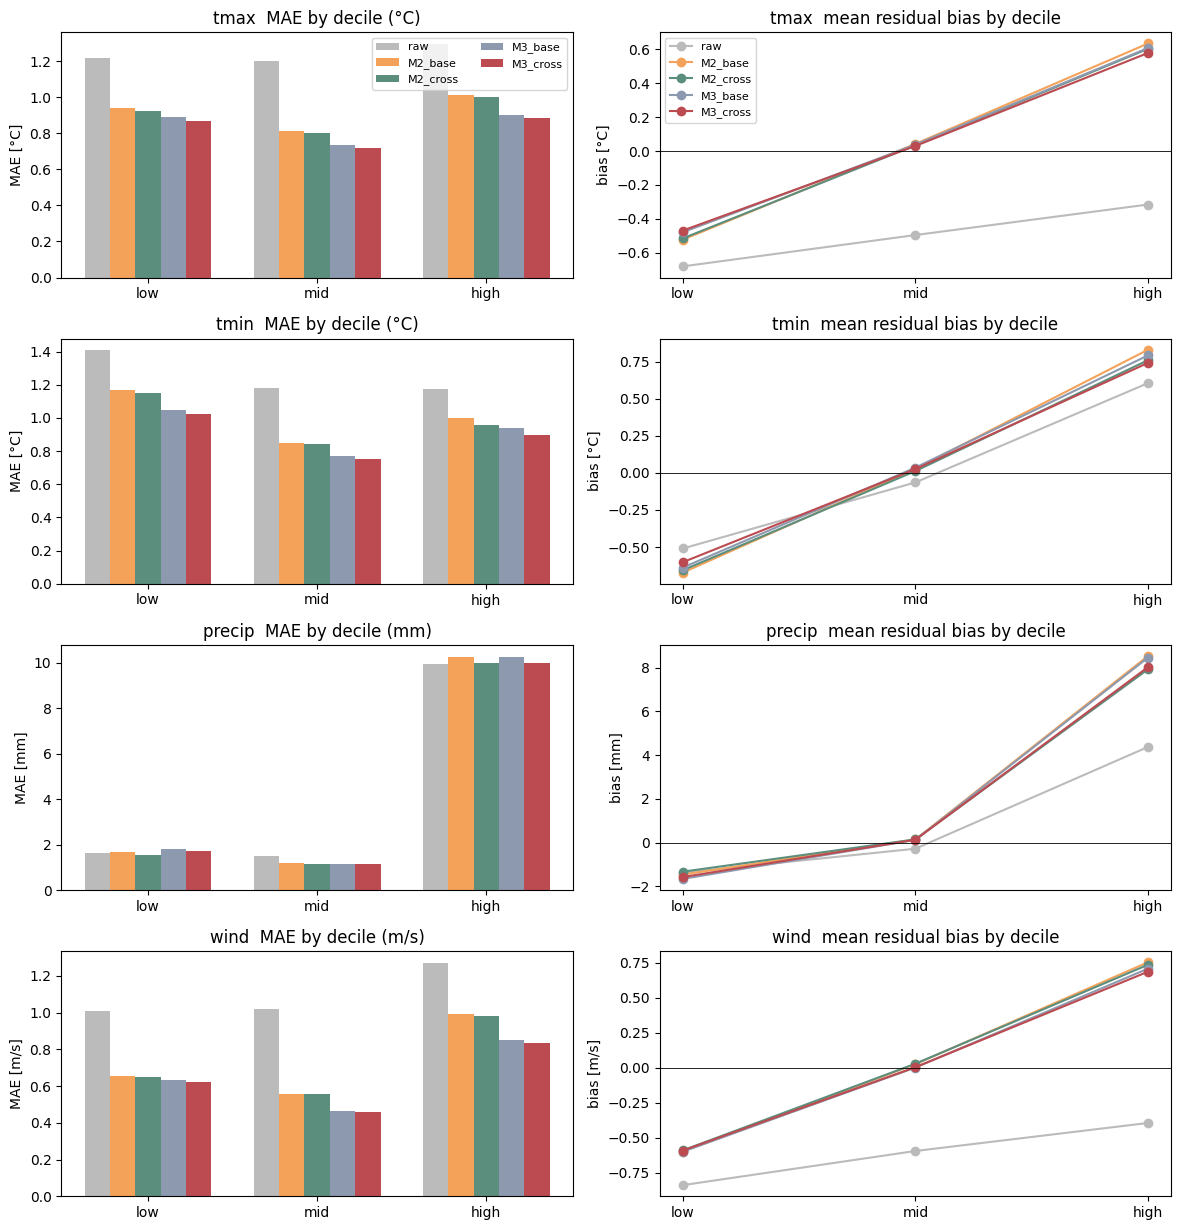

In [10]:
deciles = ['low', 'mid', 'high']
model_names = list(MODEL_COLORS)                    # raw + the four variants
fig, axes = plt.subplots(len(VARS), 2, figsize=(12, 3.1*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    ax_mae, ax_bias = axes[var_idx]
    x = np.arange(3); bar_width = 0.15
    for model_idx, model_name in enumerate(model_names):
        mae = results[var_name][model_name]['mae']
        ax_mae.bar(x + (model_idx - 2)*bar_width, [mae[d] for d in deciles],
                   bar_width, label=model_name, color=MODEL_COLORS[model_name])
    ax_mae.set_xticks(x); ax_mae.set_xticklabels(deciles)
    ax_mae.set_title(f'{var_name}  MAE by decile ({unit})'); ax_mae.set_ylabel(f'MAE [{unit}]')
    if var_idx == 0: ax_mae.legend(fontsize=8, ncol=2)
    for model_name in model_names:
        bias = results[var_name][model_name]['bias']
        ax_bias.plot(deciles, [bias[d] for d in deciles], 'o-', label=model_name,
                     color=MODEL_COLORS[model_name])
    ax_bias.axhline(0, color='k', lw=0.6); ax_bias.set_title(f'{var_name}  mean residual bias by decile')
    ax_bias.set_ylabel(f'bias [{unit}]');
    if var_idx == 0: ax_bias.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Diagnostics — version offset & feature importance

In [11]:
# raw HRES bias by forecast-model version (sanity on the version feature)
print('mean raw bias (era5 - hres) by fc_version:')
print(df.groupby('fc_version', observed=True)[[f'bias_{var["name"]}' for var in VARS]]
      .mean().round(3).to_string())

# feature importance, captured in §7 while each model was in memory
print('\nfeature importance (top 5 per variable x variant):')
for var in VARS:
    for variant in VARIANT_NAMES:
        importance = importances[(var['name'], variant)].sort_values(ascending=False)
        print(f"  {var['name']:6s} {variant:9s}: "
              + ', '.join(f'{feature}={score:.0f}'
                          for feature, score in importance.head(5).items()))

mean raw bias (era5 - hres) by fc_version:
            bias_tmax  bias_tmin  bias_precip  bias_wind
fc_version                                              
48r1           -0.542      0.069        0.046     -0.737
49r1           -0.515     -0.134        0.126     -0.532

feature importance (top 5 per variable x variant):
  tmax   M2_base  : lat=23, lon=20, hres_tmax_C=17, elev_diff_m=16, hres_elevation=7
  tmax   M2_cross : lon=19, lat=19, hres_tmax_C=18, elev_diff_m=16, hres_tmin_C=7
  tmax   M3_base  : key=34, hres_tmax_C=18, lat=13, lon=9, elev_diff_m=6
  tmax   M3_cross : key=34, hres_tmax_C=17, lat=11, lon=8, hres_tmin_C=6
  tmin   M2_base  : lat=29, elev_diff_m=15, lon=15, hres_tmin_C=14, elevation=9
  tmin   M2_cross : lat=25, elev_diff_m=16, hres_tmin_C=14, lon=12, elevation=8
  tmin   M3_base  : key=31, hres_tmin_C=19, lat=16, lon=7, elevation=7
  tmin   M3_cross : key=31, hres_tmin_C=18, lat=13, elevation=6, lon=5
  precip M2_base  : hres_precip_mm=46, lat=23, lon=15, cos_doy

## 9b. The error *tail* — what a big miss looks like, and where/when to expect it

Not cell averages. We look at the **distribution of the per-day errors** on the
test set — `err = era5 − value` for every cell×day — and zoom into its tail. We
carry **all four variants** through, in the same colors as §8, because the tail
is exactly where they diverge: **M2** variants use every feature *except* the
cell identity while **M3** variants add the cell `key` as a categorical, and
**cross** variants add the other variables' HRES values on top of **base**'s
geo/season/version features. Comparing them shows how much of the tail
correction comes from knowing the *specific cell* versus the general signal —
and how much the cross features buy on top.

1. **What a high error looks like.** Tail percentiles of `|error|` (p50 → p99.9 →
   max), raw vs each variant, plus a **histogram** of all signed errors per
   metric. "A 1-in-100 bad day for tmax is ≥ X °C; the worst was Y °C." This sets a
   concrete `THR` = 99th-pctile of raw `|error|` per variable = our **big miss**.
2. **Concrete worst events.** The literal 12 largest single day×cell misses per
   variable — date, cell, lat/lon, season, the era5 truth, the served hres value,
   and the signed error before and after each variant. The *what / where / when*
   in one table.
3. **When.** Of all big-miss days, how they split by **season** and by
   value-**decile** — and whether each variant reduces *how many* big-miss days
   there are.
4. **Where.** Per cell: its worst single day, its `|error|` p99, and its count of
   big-miss days (raw vs after each variant). Mapped, so the geography of the
   extremes is visible.
5. **Q-Q (worst cells).** For the cells with the most big-miss days, quantile-quantile
   plots of forecast vs ERA5 truth — raw and all four corrected against the 45° line.
   Shows *how* the forecast distribution is biased at the tails (e.g. precip clipping
   heavy rain) and whether the models pull it onto the diagonal.

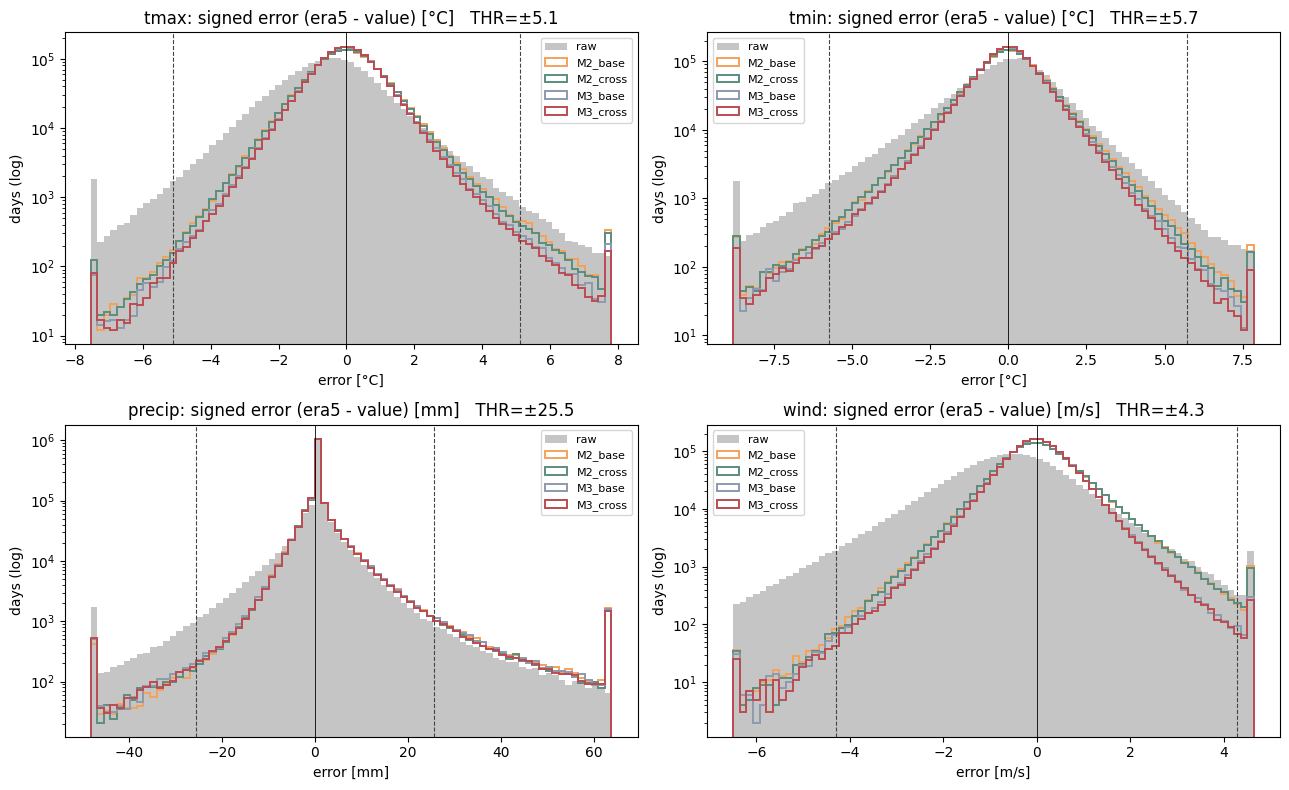

== |error| tail: the bad days, raw vs each variant (not averages) ==
        var pctile  raw_|err|  M2_base_|err|  M2_cross_|err|  M3_base_|err|  M3_cross_|err|
  tmax (°C)    p50       0.92           0.64            0.63           0.58            0.57
  tmax (°C)    p90       2.59           1.81            1.79           1.64            1.61
  tmax (°C)    p99       5.12           3.62            3.55           3.27            3.20
  tmax (°C)  p99.9       9.24           6.02            5.94           5.48            5.34
  tmax (°C)    max      24.99          18.82           18.64          18.12           18.05
  tmin (°C)    p50       0.87           0.65            0.65           0.59            0.58
  tmin (°C)    p90       2.66           1.99            1.97           1.80            1.75
  tmin (°C)    p99       5.72           4.10            4.04           3.70            3.63
  tmin (°C)  p99.9       9.84           6.64            6.57           6.16            6.07
  tmin (°C)

In [22]:
# Per-day test errors for raw (do-nothing) vs ALL FOUR variants. We keep every
# row's SIGNED error (era5 - value) and work with the distribution, not cell
# averages. The corrected values were computed once in §7 from each fit's q50 —
# nothing re-predicts here. M2 = cell-agnostic, M3 = + cell key; base/cross =
# without/with the other variables' HRES values. Carrying all four shows how
# much of the tail fix needs the specific cell, and what the cross features buy.
errors_by_var, big_miss_threshold = {}, {}
for var in VARS:
    var_name = var['name']
    test = test_by_var[var_name].copy()
    test['err_raw'] = test[era5_col(var_name)].to_numpy() - test[hres_col(var_name)].to_numpy()
    test['ae_raw']  = test['err_raw'].abs()
    for variant in VARIANT_NAMES:
        corrected = q50_corrected[var_name][variant].astype(np.float64)
        test[variant]          = corrected               # the corrected value itself
        test[f'err_{variant}'] = test[era5_col(var_name)].to_numpy() - corrected
        test[f'ae_{variant}']  = test[f'err_{variant}'].abs()
    test['month'] = test['date'].dt.month
    errors_by_var[var_name] = test
    big_miss_threshold[var_name] = float(test['ae_raw'].quantile(0.99))

# Histogram of ALL signed errors per metric: raw (filled) vs each variant (step
# outlines, shared §8 palette), on a log count axis so the tails are visible.
# Dashed lines = +/- the raw 99th-pctile |error| (the big-miss cut).
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var in zip(axes.ravel(), VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    err_cols = ['err_raw'] + [f'err_{variant}' for variant in VARIANT_NAMES]
    lo_edge = float(min(test[c].quantile(0.001) for c in err_cols))
    hi_edge = float(max(test[c].quantile(0.999) for c in err_cols))
    bins = np.linspace(lo_edge, hi_edge, 80)
    ax.hist(test['err_raw'].clip(lo_edge, hi_edge), bins=bins, color=MODEL_COLORS['raw'], alpha=0.85, label='raw')
    for variant in VARIANT_NAMES:
        ax.hist(test[f'err_{variant}'].clip(lo_edge, hi_edge), bins=bins,
                color=MODEL_COLORS[variant], histtype='step', lw=1.4, label=variant)
    ax.axvline(0, color='k', lw=0.6)
    ax.axvline( big_miss_threshold[var_name], color='#444', ls='--', lw=0.8)
    ax.axvline(-big_miss_threshold[var_name], color='#444', ls='--', lw=0.8)
    ax.set_yscale('log')
    ax.set_title(f'{var_name}: signed error (era5 - value) [{unit}]   THR=±{big_miss_threshold[var_name]:.1f}')
    ax.set_xlabel(f'error [{unit}]'); ax.set_ylabel('days (log)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# What a "high error" looks like: tail percentiles of |error|, raw vs each variant.
tail_rows = []
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    for pctile_label, quantile in [('p50',.5), ('p90',.9), ('p99',.99), ('p99.9',.999)]:
        tail_rows.append({'var': f'{var_name} ({unit})', 'pctile': pctile_label,
                     'raw_|err|': test['ae_raw'].quantile(quantile),
                     **{f'{variant}_|err|': test[f'ae_{variant}'].quantile(quantile)
                        for variant in VARIANT_NAMES}})
    tail_rows.append({'var': f'{var_name} ({unit})', 'pctile': 'max',
                 'raw_|err|': test['ae_raw'].max(),
                 **{f'{variant}_|err|': test[f'ae_{variant}'].max()
                    for variant in VARIANT_NAMES}})
print('== |error| tail: the bad days, raw vs each variant (not averages) ==')
print(pd.DataFrame(tail_rows).round(2).to_string(index=False))
print('\nbig-miss threshold THR = raw 99th-pctile |error|:',
      {var['name']: round(big_miss_threshold[var['name']], 2) for var in VARS})

In [13]:
# The literal worst individual day x cell misses (raw), with the signed error each
# variant left behind. Concrete answer to "what does a high error look like, and
# where & when".
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    err_cols = [f'err_{variant}' for variant in VARIANT_NAMES]
    cols = ['date','key','lat','lon','season', era5_col(var_name), hres_col(var_name),
            'err_raw', *err_cols, f'dec_{var_name}']
    worst = test.nlargest(12, 'ae_raw')[cols].copy()
    worst['date'] = worst['date'].dt.date
    worst = worst.rename(columns={era5_col(var_name):'era5', hres_col(var_name):'hres', f'dec_{var_name}':'decile'})
    print(f'\n=== {var_name} ({unit}) — 12 worst single-day misses (raw |err|) ===')
    print(worst.round(2).to_string(index=False))

# WHEN do big misses (raw |err| >= THR) happen — by season and value-decile — and
# does each variant cut HOW MANY big-miss days there are?
print('\n' + '='*70)
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    big_misses = test[test.ae_raw >= big_miss_threshold[var_name]]
    denom = max(len(big_misses), 1)
    remaining = {variant: int((test[f'ae_{variant}'] >= big_miss_threshold[var_name]).sum())
                 for variant in VARIANT_NAMES}
    print(f'\n{var_name} ({unit}): {len(big_misses)} big-miss days (|err|>={big_miss_threshold[var_name]:.1f}); '
          + '; '.join(f'after {variant}: {count} ({100*(1-count/denom):+.0f}%)'
                      for variant, count in remaining.items()))
    print('  by season:', {season:int(count) for season,count in big_misses.groupby("season").size().items()})
    print('  by value-decile:', {decile:int(count) for decile,count in big_misses.groupby(f"dec_{var_name}").size().items()})


=== tmax (°C) — 12 worst single-day misses (raw |err|) ===
      date       key       lat       lon season       era5  hres    err_raw  err_M2_base  err_M2_cross  err_M3_base  err_M3_cross decile
2025-01-27 35.9_74.3 35.900002 74.300003    DJF -14.090000  10.9 -24.990000       -18.82        -18.64       -18.12        -18.05    low
2025-01-26 35.9_74.3 35.900002 74.300003    DJF -15.680000   7.0 -22.680000       -16.52        -16.42       -15.21        -15.44    low
2025-01-28 35.9_74.3 35.900002 74.300003    DJF -10.650000  10.6 -21.250000       -15.09        -14.95       -14.34        -14.34    mid
2025-01-09 35.9_74.3 35.900002 74.300003    DJF -16.340000   4.7 -21.040001       -14.81        -14.86       -12.87        -13.90    low
2025-01-10 35.9_74.3 35.900002 74.300003    DJF -16.870001   4.0 -20.870001       -14.66        -14.89       -12.72        -13.93    low
2025-01-25 35.9_74.3 35.900002 74.300003    DJF -18.200001   2.6 -20.799999       -14.91        -15.05       -13.07   


=== tmax (°C) — 10 cells with the biggest single-day misses ===
            days    p99_raw    max_raw        lat         lon  big_raw  big_M2_base  big_M2_cross  big_M3_base  big_M3_cross
key                                                                                                                         
35.9_74.3    183  21.510000  24.990000  35.900002   74.300003      146           61            55           43            44
35.1_73.0    183  19.540001  19.650000  35.099998   73.000000      183           22            33           21            27
30.4_-9.6    183  16.040001  18.459999  30.400000   -9.600000       78           62            61           53            56
34.5_66.3    183  13.760000  16.860001  34.500000   66.300003       41           17            17           15            12
-6.0_145.0   183  14.960000  16.309999  -6.000000  145.000000      183            0             0            0             0
-22.7_14.5   183  15.560000  16.070000 -22.700001   14.50000

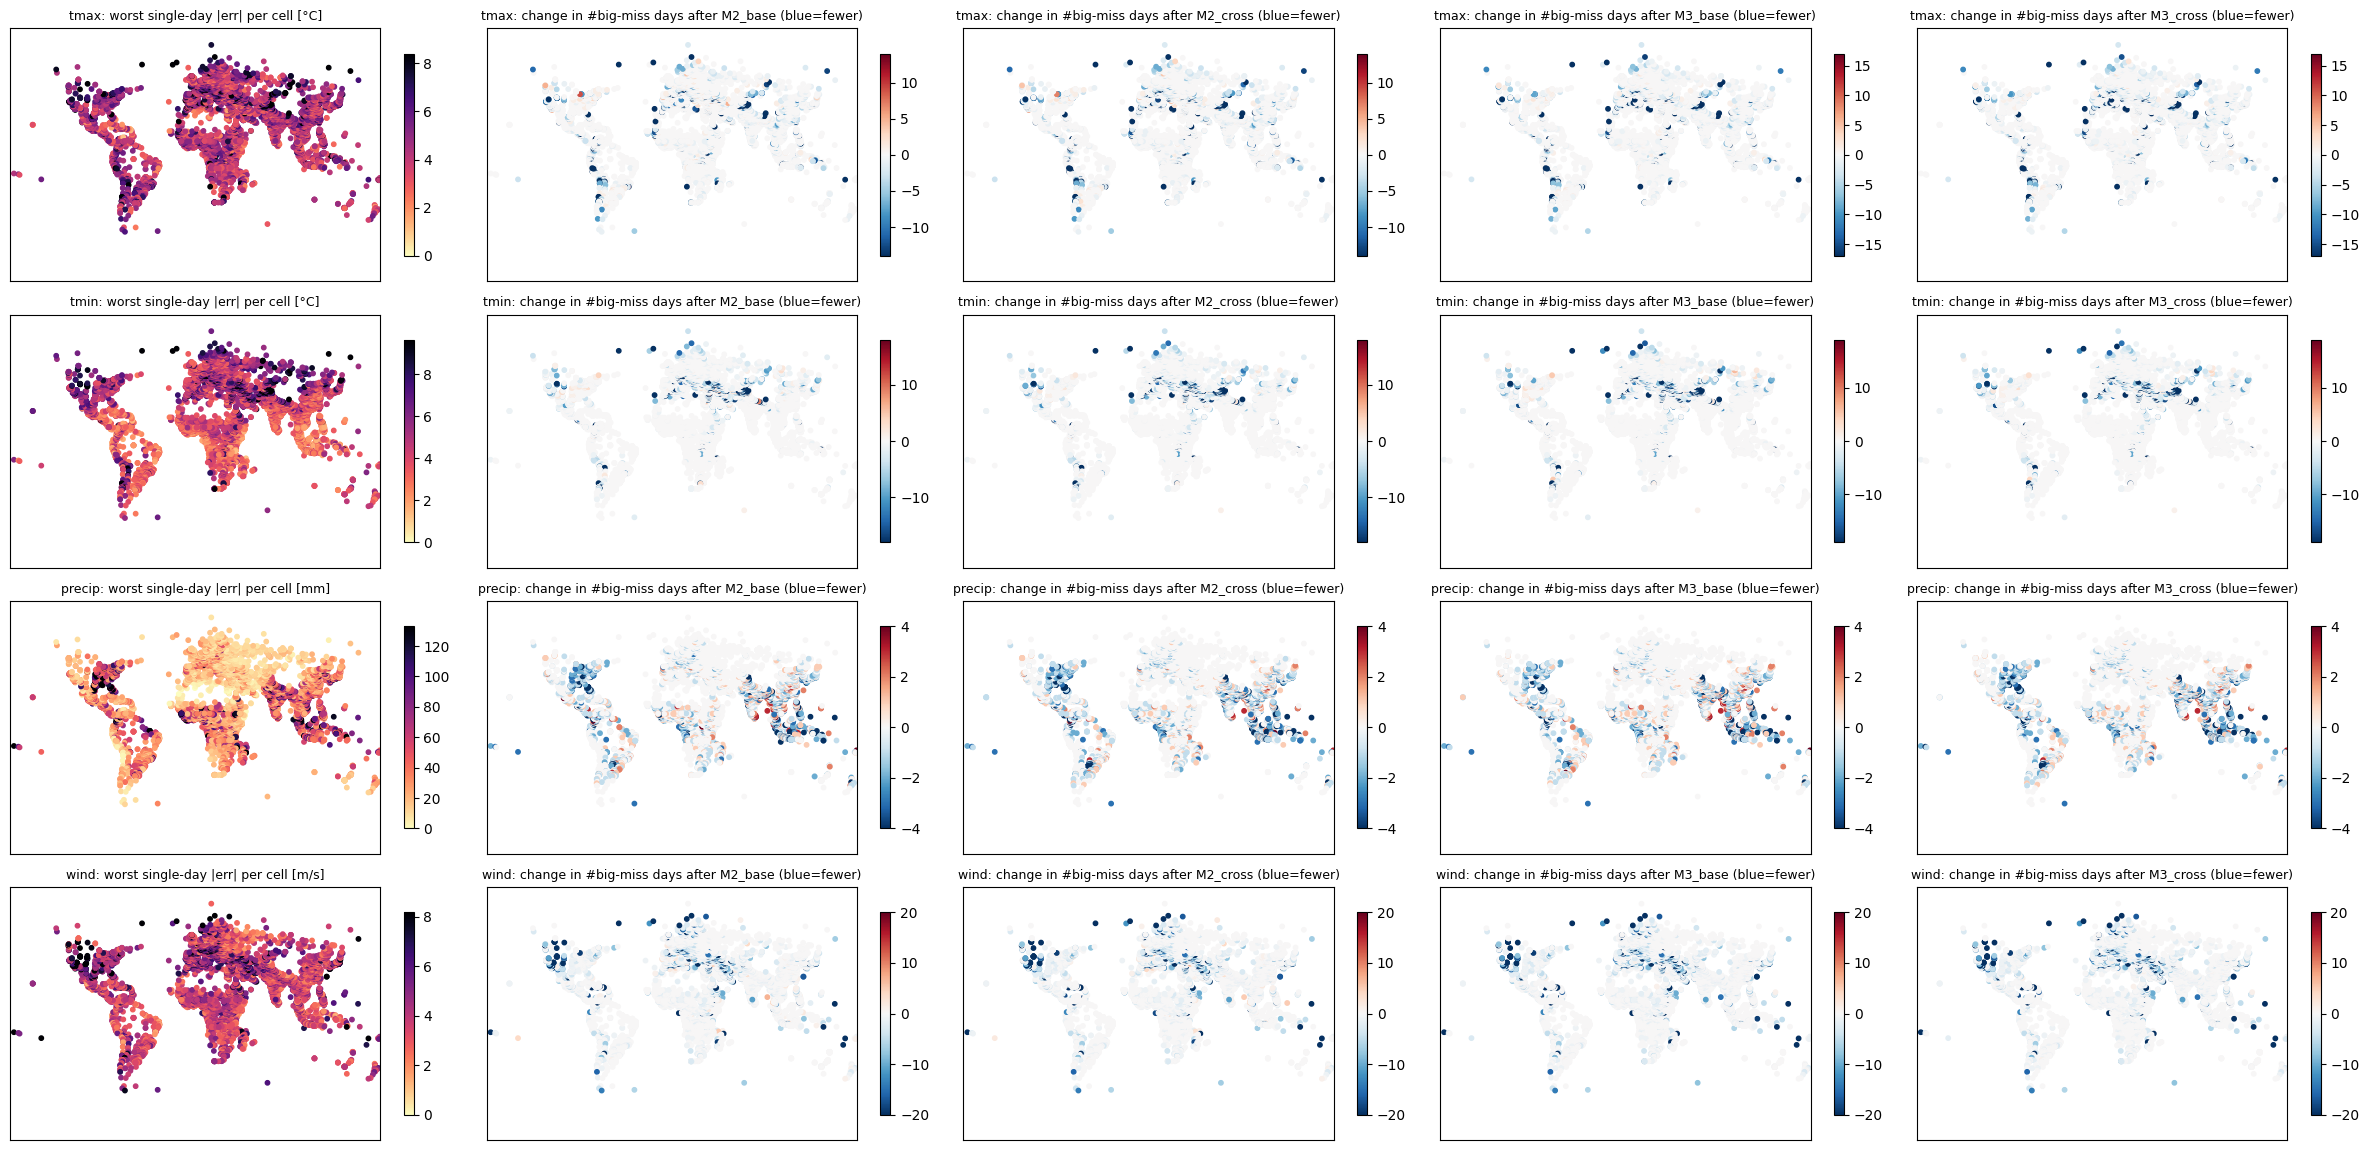

In [14]:
# WHERE the big errors live. Per cell: its worst single day, its |err| p99, and its
# count of big-miss days (raw vs after each variant). Listed, then mapped.
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    per_cell = test.groupby('key').agg(days=('ae_raw','size'),
                              p99_raw=('ae_raw', lambda errs: errs.quantile(0.99)),
                              max_raw=('ae_raw','max'),
                              lat=('lat','first'), lon=('lon','first'))
    for model_name in ['raw', *VARIANT_NAMES]:
        per_cell[f'big_{model_name}'] = (test[test[f'ae_{model_name}'] >= big_miss_threshold[var_name]]
                                    .groupby('key').size().reindex(per_cell.index).fillna(0).astype(int))
    top_cells = per_cell.sort_values('max_raw', ascending=False).head(10)
    print(f'\n=== {var_name} ({unit}) — 10 cells with the biggest single-day misses ===')
    print(top_cells.round(2).to_string())

# Map: worst single-day |err| per cell (left), then the change in #big-miss days
# after each variant (blue = fewer big misses = the model helps there).
fig, axes = plt.subplots(len(VARS), 1 + len(VARIANT_NAMES), figsize=(24, 2.9*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    per_cell = test.groupby('key').agg(max_raw=('ae_raw','max'), lat=('lat','first'), lon=('lon','first'))
    big_raw = test[test.ae_raw >= big_miss_threshold[var_name]].groupby('key').size().reindex(per_cell.index).fillna(0)
    ax_worst = axes[var_idx, 0]
    worst_scatter = ax_worst.scatter(per_cell.lon, per_cell.lat, c=per_cell.max_raw, s=10, cmap='magma_r',
                     vmin=0, vmax=per_cell.max_raw.quantile(0.98))
    ax_worst.set_title(f'{var_name}: worst single-day |err| per cell [{unit}]', fontsize=9)
    fig.colorbar(worst_scatter, ax=ax_worst, shrink=0.8)
    for ax_delta, variant in zip(axes[var_idx, 1:], VARIANT_NAMES):
        big_model = test[test[f'ae_{variant}'] >= big_miss_threshold[var_name]].groupby('key').size().reindex(per_cell.index).fillna(0)
        delta = big_model - big_raw                       # negative = fewer big misses after the model
        delta_lim = max(1.0, float(np.abs(delta).quantile(0.98)))
        delta_scatter = ax_delta.scatter(per_cell.lon, per_cell.lat, c=delta, s=10, cmap='RdBu_r', vmin=-delta_lim, vmax=delta_lim)
        ax_delta.set_title(f'{var_name}: change in #big-miss days after {variant} (blue=fewer)', fontsize=9)
        fig.colorbar(delta_scatter, ax=ax_delta, shrink=0.8)
    for ax in axes[var_idx]:
        ax.set_xlim(-180,180); ax.set_ylim(-90,90); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

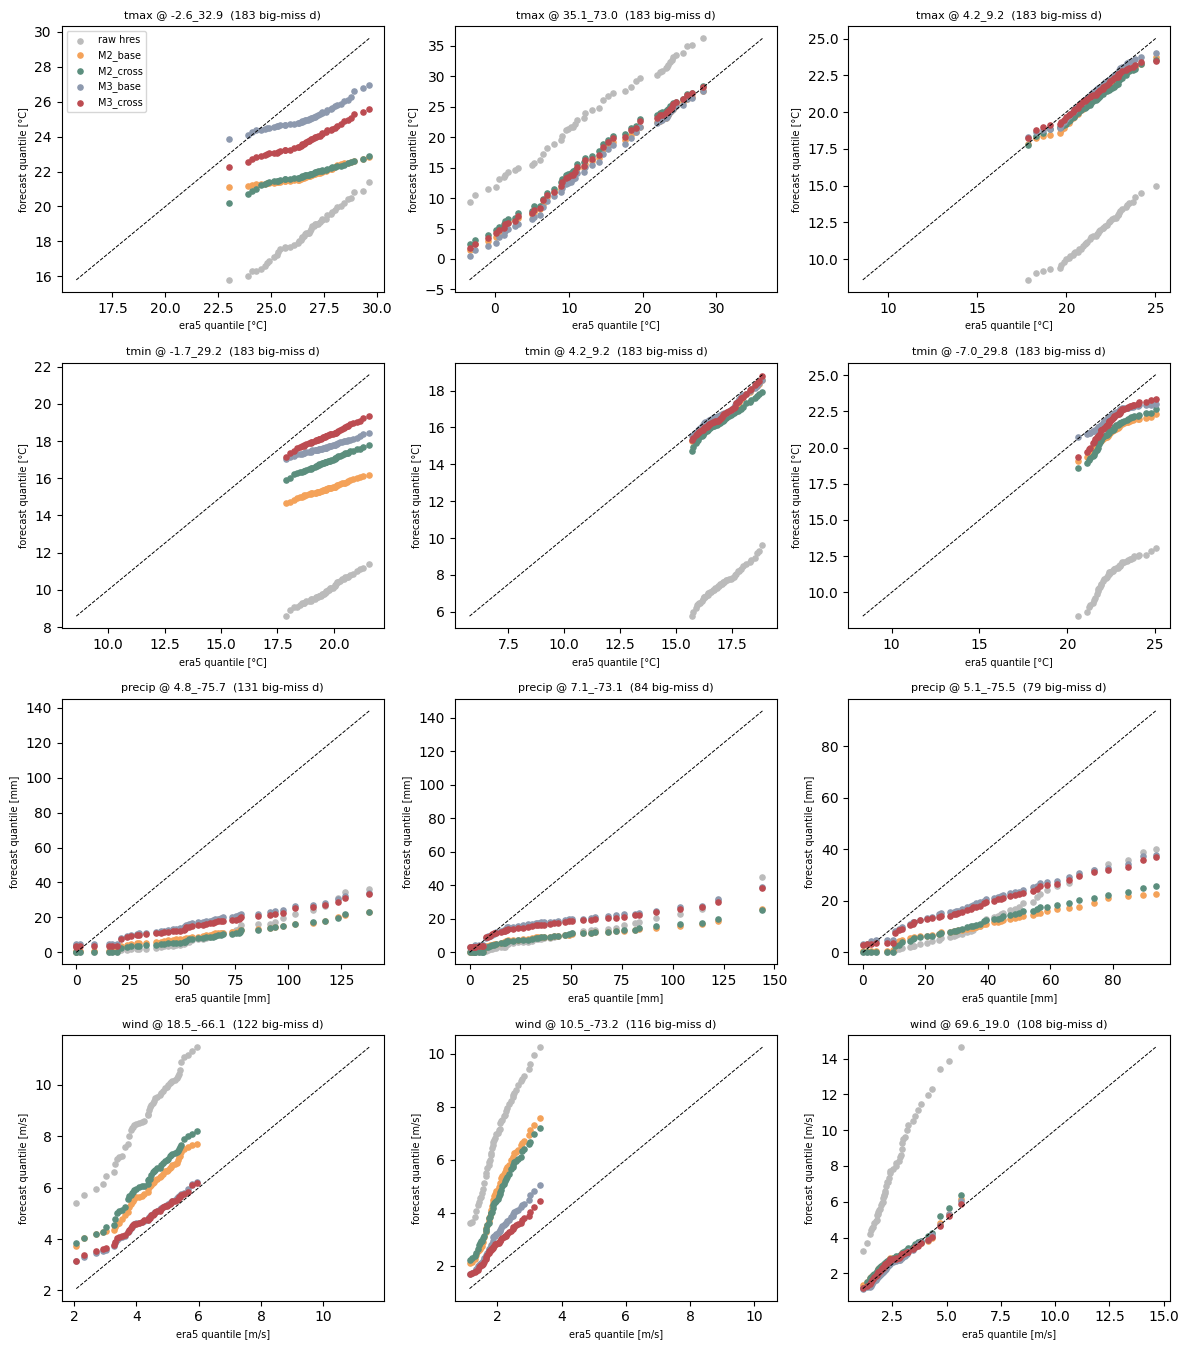

In [15]:
# Q-Q plots for the worst cells per metric: do the forecast's quantiles line up with
# ERA5 truth, and do the variants pull them onto the diagonal? "Worst" = most big-miss
# days (raw |err| >= THR). Gray = raw hres vs era5; the four variants use the shared
# §8 palette; the dashed 45-deg line is perfect agreement. Departure at the ends =
# tail bias.
quantile_levels = np.linspace(0.02, 0.98, 49)
N_WORST = 3                              # worst cells shown per metric
fig, axes = plt.subplots(len(VARS), N_WORST, figsize=(4*N_WORST, 3.4*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    big_by_cell = test[test.ae_raw >= big_miss_threshold[var_name]].groupby('key').size().sort_values(ascending=False)
    worst_keys = big_by_cell.head(N_WORST).index.tolist()
    for col_idx, cell_key in enumerate(worst_keys):
        ax = axes[var_idx, col_idx]
        cell_rows = test[test.key == cell_key]
        truth_q = cell_rows[era5_col(var_name)].quantile(quantile_levels).to_numpy()
        model_q = {'raw': cell_rows[hres_col(var_name)].quantile(quantile_levels).to_numpy(),
                   **{variant: cell_rows[variant].quantile(quantile_levels).to_numpy()
                      for variant in VARIANT_NAMES}}
        lo_val = float(min(truth_q.min(), *(q.min() for q in model_q.values())))
        hi_val = float(max(truth_q.max(), *(q.max() for q in model_q.values())))
        ax.plot([lo_val, hi_val], [lo_val, hi_val], 'k--', lw=0.7)
        for model_name, model_quantiles in model_q.items():
            ax.scatter(truth_q, model_quantiles, s=14, color=MODEL_COLORS[model_name],
                       label='raw hres' if model_name == 'raw' else model_name)
        ax.set_title(f'{var_name} @ {cell_key}  ({int(big_by_cell[cell_key])} big-miss d)', fontsize=8)
        ax.set_xlabel(f'era5 quantile [{unit}]', fontsize=7)
        ax.set_ylabel(f'forecast quantile [{unit}]', fontsize=7)
        if var_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 9c. Where M2 and M3 *disagree* — Q-Q on the cells they treat most differently

§9b's last plot ranked cells by raw big-miss days. Here we instead pick the cells
where **M2_cross and M3_cross diverge the most**: `mean |M2_cross − M3_cross|`
over the cell's test days. Because `err_M2_cross − err_M3_cross = M3_cross −
M2_cross`, that gap is exactly *how much adding the cell key (M3) moves the
correction away from the cell-agnostic model (M2)* — so these are the cells where
knowing the specific cell buys the most (or where M3 risks over-fitting it). Same
Q-Q layout and colors as 9b: 3 cells per metric, forecast vs ERA5 quantiles, raw
and all four variants against the 45° line — the base variants ride along so the
same gap is visible without the cross features.

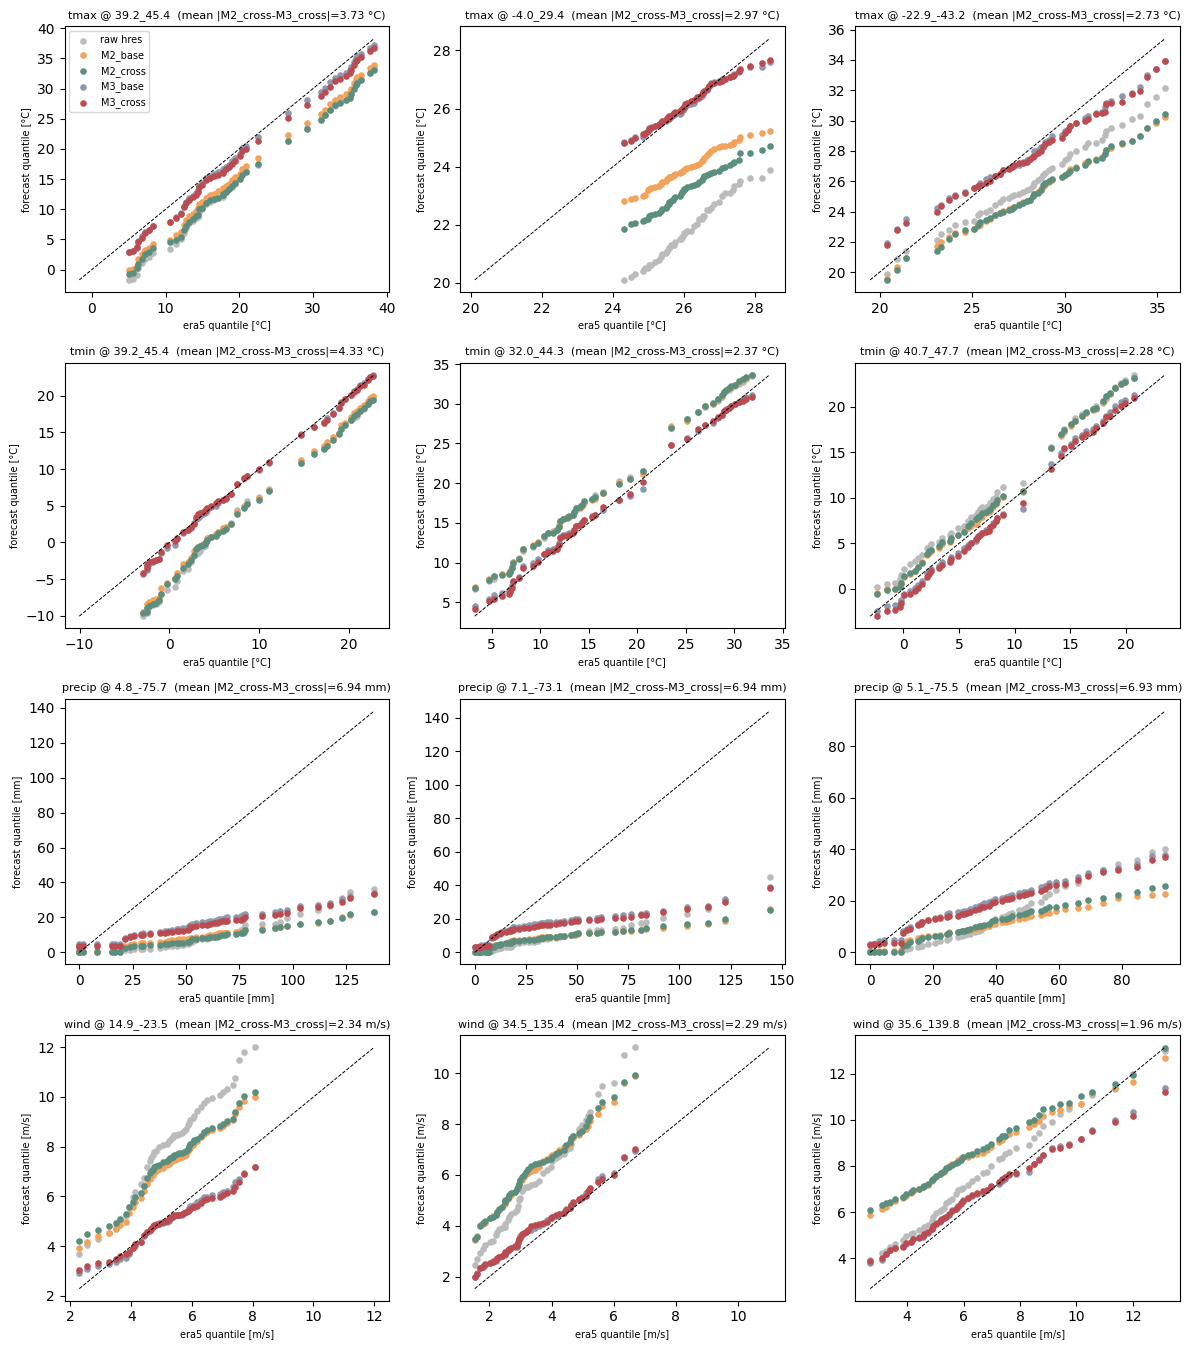

In [16]:
# Q-Q plots for the cells where M2_cross and M3_cross DISAGREE most per metric --
# companion to 9b's last plot, which ranked cells by raw big-miss days. Here
# "worst" = largest mean |M2_cross - M3_cross| over the cell's test days
# (err_M2_cross - err_M3_cross = M3_cross - M2_cross, so this is exactly where
# adding the cell key shifts the correction the most). Same layout and shared
# palette as 9b; the base variants are drawn too, so the same cell-key gap is
# visible without the cross features.
quantile_levels = np.linspace(0.02, 0.98, 49)
N_DIVERGE = 3                            # cells shown per metric
MIN_DAYS  = 30                           # skip cells too small for a stable mean / quantiles
fig, axes = plt.subplots(len(VARS), N_DIVERGE, figsize=(4*N_DIVERGE, 3.4*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    m2_m3_gap = (test['M2_cross'] - test['M3_cross']).abs()
    per_cell_gap = m2_m3_gap.groupby(test['key']).agg(['mean', 'size'])
    diff_by_cell = per_cell_gap[per_cell_gap['size'] >= MIN_DAYS]['mean'].sort_values(ascending=False)
    diverge_keys = diff_by_cell.head(N_DIVERGE).index.tolist()
    for col_idx, cell_key in enumerate(diverge_keys):
        ax = axes[var_idx, col_idx]
        cell_rows = test[test.key == cell_key]
        truth_q = cell_rows[era5_col(var_name)].quantile(quantile_levels).to_numpy()
        model_q = {'raw': cell_rows[hres_col(var_name)].quantile(quantile_levels).to_numpy(),
                   **{variant: cell_rows[variant].quantile(quantile_levels).to_numpy()
                      for variant in VARIANT_NAMES}}
        lo_val = float(min(truth_q.min(), *(q.min() for q in model_q.values())))
        hi_val = float(max(truth_q.max(), *(q.max() for q in model_q.values())))
        ax.plot([lo_val, hi_val], [lo_val, hi_val], 'k--', lw=0.7)
        for model_name, model_quantiles in model_q.items():
            ax.scatter(truth_q, model_quantiles, s=14, color=MODEL_COLORS[model_name],
                       label='raw hres' if model_name == 'raw' else model_name)
        ax.set_title(f'{var_name} @ {cell_key}  (mean |M2_cross-M3_cross|={diff_by_cell[cell_key]:.2f} {unit})', fontsize=8)
        ax.set_xlabel(f'era5 quantile [{unit}]', fontsize=7)
        ax.set_ylabel(f'forecast quantile [{unit}]', fontsize=7)
        if var_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 9d. Reading the results, the precip caveat, and shipping

**Tail metric.** `tailMAE = ½(low-decile MAE + high-decile MAE)` weights both
extremes equally; the center (`mid`) is reported but not in the headline. The
same idea at 1% (`tail1MAE`) checks the 1-in-100 days. The fits themselves are
unweighted (see §4) — the tails are enforced by *measuring* them, not by
skewing the loss.

**Temperature (tmax/tmin).** The additive GBT correction should beat a constant
per-cell offset at the tails, because `hres` (the level) lets it learn a
*level-dependent* bias. M3's `key` categorical adds a per-cell residual on top;
the cross variants also see the other variables' HRES values, so the correction
can depend on the weather *regime* (e.g. tmax bias on windy vs calm days).

**Precip caveat (expect this).** Additive debiasing improves precip in the bulk
but often **not at the tails**: IFS over-produces drizzle (dry tail) and clips
heavy-rain peaks (wet tail), a skewed/multiplicative error an additive tree fit
can't undo. If precip tails matter, the right tool is **quantile mapping** (fit
the ERA5↔HRES CDF per cell×season and remap), or a multiplicative/log-space
target — a separate follow-up, not this additive model. Wind sits between temp
and precip.

**Shipping (next step).** Gate per cell×var on `per_cell_{TAG}.csv` (§7b), then
apply the chosen fit in the serving path as `corrected = clip(hres + q50, 0…)`
for recent/forecast days — with the outer quantile pairs as the 90%/98%
uncertainty bands — so served days land on the ERA5-Land scale the percentiles
use.

In [17]:
# The trainer persists everything to models/: {variant}_{var}_{TAG}.cbm plus
# spec_{TAG}.json, eval_{TAG}.csv and per_cell_{TAG}.csv (TAG = qn{cells}_s{seed}).
# To reuse the shipped debiaser in the serving path:
#
# from catboost import CatBoostRegressor
# from train_quantile_debias import feature_cols, hres_col, Q50
# model = CatBoostRegressor()
# model.load_model(str(MODELS / f'M3_cross_{var}_{TAG}.cbm'))
# def debias(feature_row, nonneg):
#     """corrected forecast value (ERA5-Land scale) for one day/cell."""
#     quantiles = model.predict(feature_row[feature_cols(var, True, True)])
#     corrected = feature_row[hres_col(var)] + quantiles[Q50]
#     return float(np.clip(corrected, 0, None)) if nonneg else float(corrected)
print('notebook complete.')

notebook complete.


## 10. Uncertainty bands — MQ vs CQR vs per-decile CQR, across all four variants

Every variant is a MultiQuantile model, so each one ships a native 90% band
(`q05..q95`) — *input-adaptive* (width follows the features) but with **no
coverage guarantee**. Three band constructions, for each of the four variants
(`M2_base`, `M3_base`, `M2_cross`, `M3_cross`):

- **MQ** — the model band exactly as shipped.
- **CQR** — the same band widened/tightened by ONE conformal scalar `Q`
  calibrated on held-out rows → adaptive **and** marginally calibrated.
- **CQR·dec** — Mondrian (group-conditional) CQR: a separate `Q` per
  **forecast-decile** (`fdec`: is the HRES value in the bottom 10% / middle /
  top 10% for that cell × season) → the 0.90 guarantee holds *within each
  forecast-decile*, not just on average.

**The leak, fixed.** The truth-deciles (`dec`) rank the ERA5 *outcome*, which
is unknown at prediction time — calibrating a per-decile `Q` on them would
condition on the answer (the same quiet cheat the retired `Empirical (decile)`
baseline made). `fdec` ranks the HRES *forecast* instead: X-measurable, so
Mondrian calibration on it is valid and shippable. Truth-deciles stay in the
tables/plots **as an evaluation axis only** — no method can guarantee coverage
on a y-defined event; CQR·dec helps there exactly as far as the forecast
predicts which days end up truth-extreme.

Read it as a three-step argument: CQR pins every variant's *marginal* coverage
to ~0.90; CQR·dec additionally pins it within every forecast-decile (the
`fcov_*` columns); the fair yardstick after calibration is **width** — the
variant that buys the sharpest honest band wins. The spread of the per-decile
`Q`s is a one-line diagnosis of what a single global `Q` papers over.

The test rows are split into exchangeable calibration / evaluation halves —
one split per variable, shared by all variants and methods, so every band is
scored on the same rows. Coverage is on the modelled target
`bias = era5 − hres` (for precip/wind the downstream `clip(0)` on the
*corrected value* shifts real-world coverage slightly — noted, not modelled).

Caveats: split-conformal assumes exchangeability, which time-ordered data
mildly violates; and `fdec` ranks each day against the pooled archive (in
production you'd rank against trailing climatology — same to first order).
Requires §3 (it builds `fdec`) and §7 (it stores every variant's sorted
`[q05, q95]` band columns) to have re-run.


In [18]:
# === 12a. 90% bands — MQ (as shipped) vs CQR vs CQR·dec, for ALL FOUR variants ===
# Works off §7's stored band_preds (per variant: the sorted (n_test, 2)
# [q05, q95] columns) — no model loads; everything here is cheap arithmetic.
# CQR·dec calibrates one Q per FORECAST-decile (fdec, known at prediction
# time) — never per truth-decile (dec), which would condition on the target.
NOM = 0.90
rng = np.random.default_rng(SEED)
FDEC_GROUPS = ('low', 'mid', 'high')

def conformal_q(scores):
    rank = min(int(np.ceil((len(scores) + 1) * NOM)), len(scores))
    return float(np.sort(scores)[rank - 1])

def coverage_and_sharpness(truth, lower, upper, truth_decile, forecast_decile):
    inside = (truth >= lower) & (truth <= upper); width = upper - lower
    out = {'cov_all': float(inside.mean()), 'width_all': float(width.mean()), 'n': int(len(truth))}
    for decile_name in FDEC_GROUPS:
        mask = truth_decile == decile_name
        out[f'cov_{decile_name}']  = float(inside[mask].mean())  if mask.any()  else float('nan')
        fmask = forecast_decile == decile_name
        out[f'fcov_{decile_name}'] = float(inside[fmask].mean()) if fmask.any() else float('nan')
    return out

coverage_rows, q_rows, bands_by_var = [], [], {}
for var in VARS:
    var_name = var['name']
    test = test_by_var[var_name]
    y = test[f'bias_{var_name}'].to_numpy()
    decile = test[f'dec_{var_name}'].to_numpy()      # truth-decile: EVALUATION only
    fdec = test[f'fdec_{var_name}'].to_numpy()       # forecast-decile: legal to calibrate on
    hres_values = test[hres_col(var_name)].to_numpy()
    calib_mask = rng.random(len(test)) < 0.5   # ONE calib/eval split per var, shared by all variants
    y_calib, y_eval = y[calib_mask], y[~calib_mask]
    decile_eval = decile[~calib_mask]
    fdec_calib, fdec_eval = fdec[calib_mask], fdec[~calib_mask]
    bands_by_var[var_name] = {'y_eval': y_eval, 'decile_eval': decile_eval,
                              'fdec_eval': fdec_eval,
                              'hres': hres_values[~calib_mask], 'unit': var['unit'],
                              'variants': {}}
    for variant in VARIANT_NAMES:
        band = band_preds[var_name][variant].astype(np.float64)   # sorted [q05, q95]
        lo_calib, hi_calib = band[calib_mask, 0], band[calib_mask, 1]
        lo_eval,  hi_eval  = band[~calib_mask, 0], band[~calib_mask, 1]
        conformity_scores = np.maximum(lo_calib - y_calib, y_calib - hi_calib)

        cqr_q = conformal_q(conformity_scores)                      # one global Q
        cqr_q_dec = {group: conformal_q(conformity_scores[fdec_calib == group])
                     for group in FDEC_GROUPS}                      # Mondrian: one Q per fdec group
        q_per_row = pd.Series(fdec_eval).map(cqr_q_dec).to_numpy(np.float64)

        methods = {'MQ':      (lo_eval, hi_eval),
                   'CQR':     (lo_eval - cqr_q, hi_eval + cqr_q),
                   'CQR·dec': (lo_eval - q_per_row, hi_eval + q_per_row)}
        bands_by_var[var_name]['variants'][variant] = {'methods': methods,
                                                       'Q': cqr_q, 'Q_dec': cqr_q_dec}
        q_rows.append({'var': var_name, 'variant': variant, 'Q': cqr_q,
                       **{f'Q_{group}': cqr_q_dec[group] for group in FDEC_GROUPS}})
        for method_name, (lower, upper) in methods.items():
            row = coverage_and_sharpness(y_eval, lower, upper, decile_eval, fdec_eval)
            row.update(var=var_name, variant=variant, method=method_name)
            coverage_rows.append(row)
    print(f'{var_name:6s} | calib {int(calib_mask.sum()):,}  eval {len(y_eval):,}  '
          f'(calib fdec: low {int((fdec_calib == "low").sum()):,} / '
          f'high {int((fdec_calib == "high").sum()):,})')

q_table = pd.DataFrame(q_rows)
print('\n== conformal widening Q — global vs per forecast-decile (Mondrian) ==')
print('   the Q_low / Q_mid / Q_high spread = what one global Q papers over')
print(q_table.round(3).to_string(index=False))

coverage_table = pd.DataFrame(coverage_rows)[['var', 'variant', 'method', 'cov_all', 'width_all',
                                              'cov_low', 'cov_mid', 'cov_high',
                                              'fcov_low', 'fcov_mid', 'fcov_high', 'n']]
print(f'\n== 90% band (target coverage {NOM}) — coverage & mean width by variable x variant x method ==')
print('   MQ = as shipped | CQR = ± one global Q | CQR·dec = ± Q per forecast-decile')
print('   cov_*  = by TRUTH decile (diagnostic only — y-conditioned, no method can guarantee it)')
print('   fcov_* = by FORECAST decile (X-measurable — CQR·dec should pin all three to ~0.90)')
print(coverage_table.round(3).to_string(index=False))


tmax   | calib 798,205  eval 798,836  (calib fdec: low 98,813 / high 56,105)
tmin   | calib 798,124  eval 798,917  (calib fdec: low 108,666 / high 49,584)
precip | calib 798,570  eval 798,471  (calib fdec: low 9,648 / high 64,729)
wind   | calib 799,127  eval 797,914  (calib fdec: low 84,977 / high 80,830)

== conformal widening Q — global vs per forecast-decile (Mondrian) ==
   the Q_low / Q_mid / Q_high spread = what one global Q papers over
   var  variant     Q  Q_low  Q_mid  Q_high
  tmax  M2_base 0.043  0.087  0.026   0.145
  tmax M2_cross 0.042  0.050  0.031   0.148
  tmax  M3_base 0.065  0.133  0.049   0.137
  tmax M3_cross 0.060  0.093  0.050   0.125
  tmin  M2_base 0.059  0.198  0.035   0.091
  tmin M2_cross 0.048  0.156  0.029   0.082
  tmin  M3_base 0.062  0.174  0.042   0.095
  tmin M3_cross 0.049  0.128  0.035   0.094
precip  M2_base 0.000  0.000  0.000  -0.011
precip M2_cross 0.000  0.000  0.000  -0.014
precip  M3_base 0.000  0.000  0.000   0.001
precip M3_cross 0.000  0

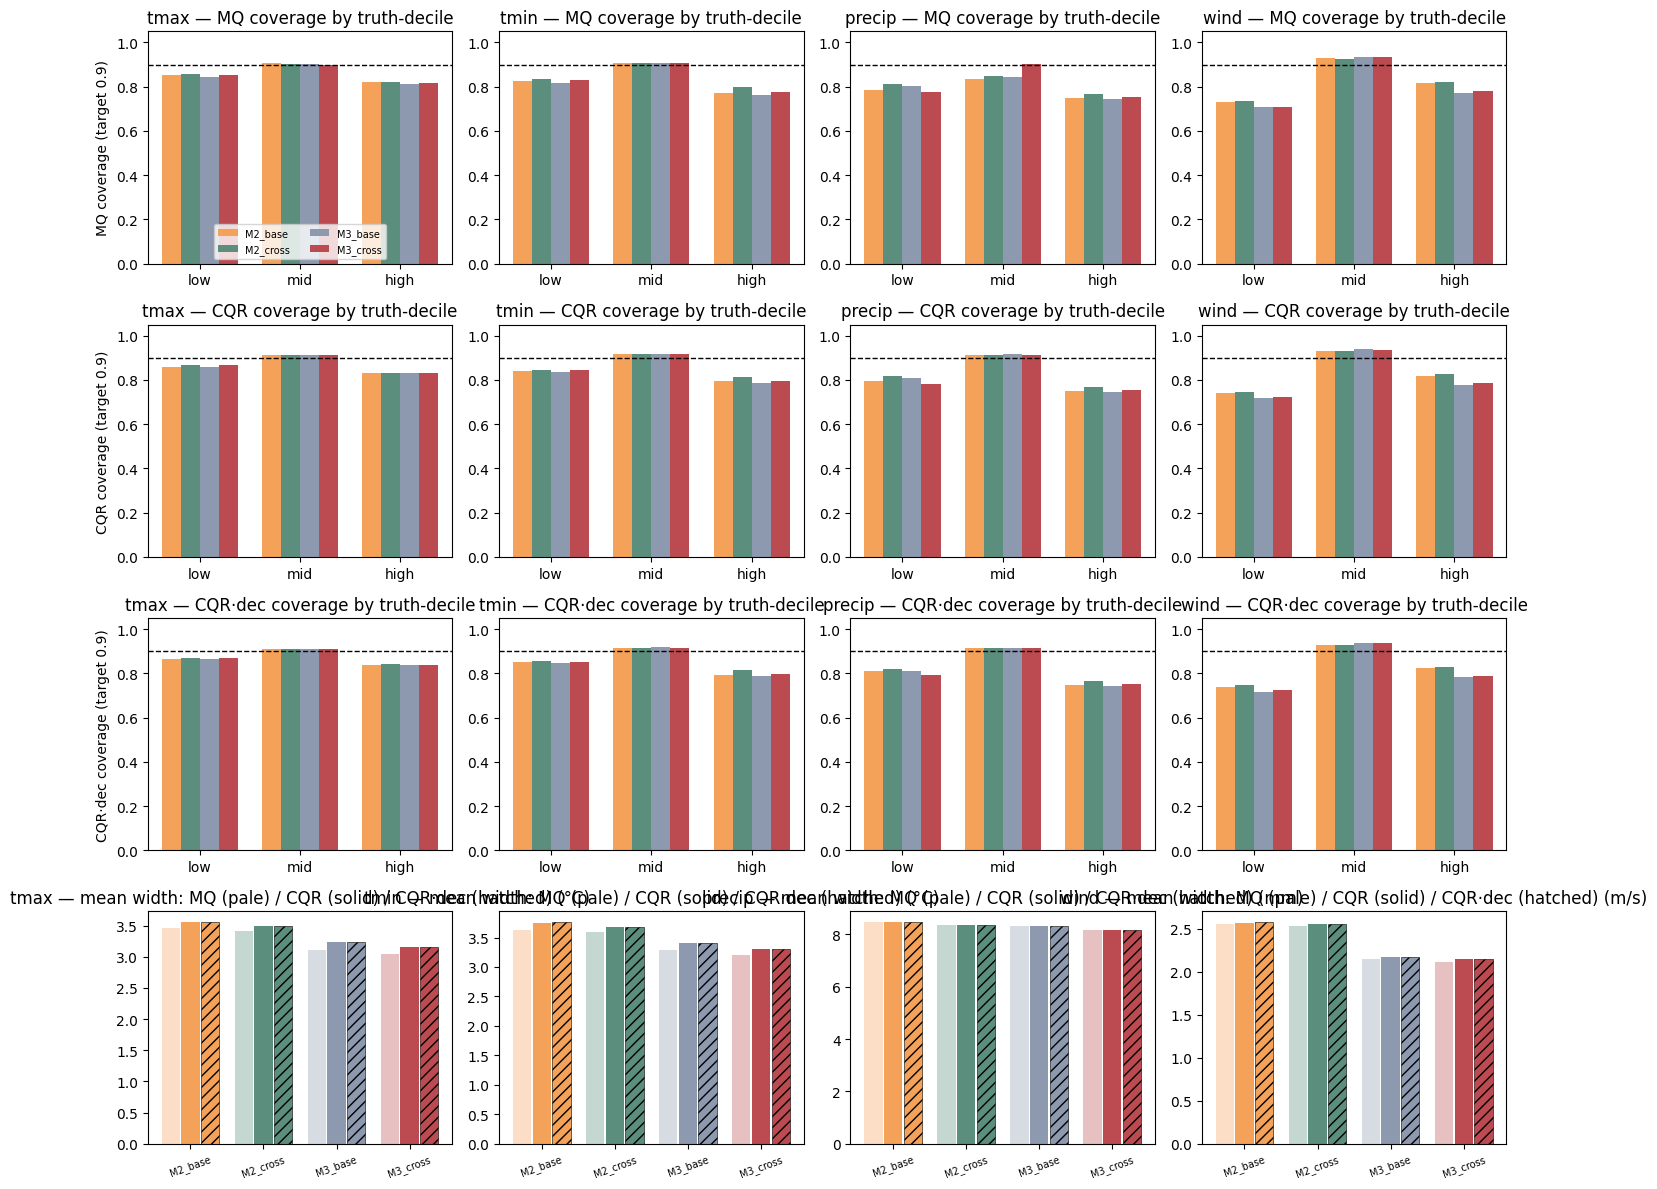

Read it like this:
  • row 1 (MQ): bars off the dashed 0.90 = the raw band is dishonest there; no guarantee.
  • row 2 (CQR): overall coverage pinned to 0.90 by construction, but one global Q cannot
    fix per-decile drift — the truth-tails (low/high) can stay under-covered.
  • row 3 (CQR·dec): a separate Q per FORECAST-decile. It guarantees the fcov_* columns in
    §12a's table; it helps these truth-decile bars only as far as the forecast predicts
    which days end up truth-extreme — any residual gap IS that predictability limit.
  • row 4: among equally-covered methods the SHORTEST bar wins. hatched vs solid = the
    price of per-decile honesty (typically wider where the raw band was thinnest).


In [19]:
# === 12b. The tradeoff, drawn: calibration (coverage) vs sharpness (width) ===
# rows 1-3: coverage by TRUTH decile (the y-conditioned diagnostic) for MQ, CQR
# and CQR·dec | row 4: mean width per variant. The forecast-decile coverage
# that CQR·dec actually guarantees is in §12a's table (fcov_*).
deciles = ['low', 'mid', 'high']
method_rows = ['MQ', 'CQR', 'CQR·dec']
fig, axes = plt.subplots(4, len(VARS), figsize=(3.6 * len(VARS), 12.0))
for var_idx, var in enumerate(VARS):
    var_name = var['name']
    var_cov = coverage_table[coverage_table['var'] == var_name].set_index(['variant', 'method'])
    for row_idx, method in enumerate(method_rows):
        ax_cov = axes[row_idx, var_idx]
        x = np.arange(len(deciles)); bar_width = 0.19
        for variant_idx, variant in enumerate(VARIANT_NAMES):
            ax_cov.bar(x + (variant_idx - 1.5) * bar_width,
                       [var_cov.loc[(variant, method), f'cov_{decile}'] for decile in deciles],
                       bar_width, label=variant, color=MODEL_COLORS[variant])
        ax_cov.axhline(NOM, color='k', ls='--', lw=1)
        ax_cov.set_xticks(x); ax_cov.set_xticklabels(deciles); ax_cov.set_ylim(0, 1.05)
        ax_cov.set_title(f'{var_name} — {method} coverage by truth-decile')
        if var_idx == 0: ax_cov.set_ylabel(f'{method} coverage (target {NOM})')
    ax_width = axes[3, var_idx]
    x = np.arange(len(VARIANT_NAMES))
    variant_colors = [MODEL_COLORS[variant] for variant in VARIANT_NAMES]
    for offset, method, alpha, hatch in ((-0.27, 'MQ',      0.35, None),
                                         ( 0.00, 'CQR',     1.00, None),
                                         ( 0.27, 'CQR·dec', 1.00, '///')):
        ax_width.bar(x + offset,
                     [var_cov.loc[(variant, method), 'width_all'] for variant in VARIANT_NAMES],
                     0.25, color=variant_colors, alpha=alpha, hatch=hatch,
                     edgecolor='black' if hatch else 'none', linewidth=0.4)
    ax_width.set_xticks(x); ax_width.set_xticklabels(VARIANT_NAMES, rotation=20, fontsize=7)
    ax_width.set_title(f'{var_name} — mean width: MQ (pale) / CQR (solid) / CQR·dec (hatched) ({var["unit"]})')
axes[0, 0].legend(fontsize=7, loc='lower center', ncol=2)
plt.tight_layout(); plt.show()

print('Read it like this:')
print('  • row 1 (MQ): bars off the dashed 0.90 = the raw band is dishonest there; no guarantee.')
print('  • row 2 (CQR): overall coverage pinned to 0.90 by construction, but one global Q cannot')
print('    fix per-decile drift — the truth-tails (low/high) can stay under-covered.')
print('  • row 3 (CQR·dec): a separate Q per FORECAST-decile. It guarantees the fcov_* columns in')
print("    §12a's table; it helps these truth-decile bars only as far as the forecast predicts")
print('    which days end up truth-extreme — any residual gap IS that predictability limit.')
print('  • row 4: among equally-covered methods the SHORTEST bar wins. hatched vs solid = the')
print('    price of per-decile honesty (typically wider where the raw band was thinnest).')


## 10b. Width up close — distribution of widths, and width vs forecast value

Two views of *sharpness/adaptivity* across all four variables and all four
variants, straight from the `bands_by_var` dict §12a built:

- **§12c** — histogram of the per-row 90% interval width, per variant: dashed =
  MQ as shipped, solid = CQR. CQR is the MQ histogram translated by +2·Q, so
  the dash→solid gap *is* each variant's honesty tax, drawn.
- **§12d** — full width *distribution* per HRES-forecast-value bin (boxplots),
  as a grid of variable × variant: grey = MQ, colored = CQR. Boxes that
  grow/shift with the value = the adaptivity CQR inherits from the band it
  wraps; compare colored boxes across columns to pick the sharpest calibrated
  band at any given forecast value.

Both views stay on the **global-Q CQR**: CQR·dec is the same band with one of
just three shifts (2·Q_low / 2·Q_mid / 2·Q_high), so its width histogram is a
three-way remix of the CQR one — §12a's `Q` table already tells that story
without four more curves per panel.


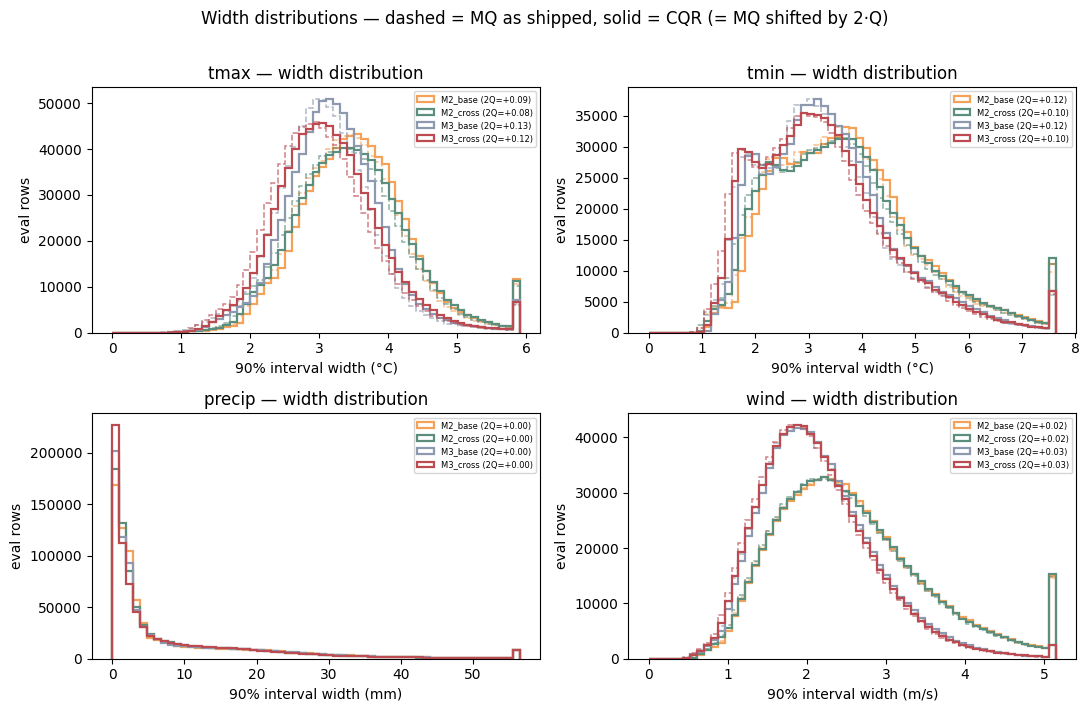

Per variant: the solid (CQR) curve is the dashed (MQ) one translated by +2·Q.
Bigger dash→solid gap = the raw band needed more widening to be honest;
among solids, the leftmost curve = the sharpest calibrated band.


In [20]:
# === 12c. Histogram of band widths — per variable, colored by variant ===
# dashed = MQ (as shipped), solid = CQR (same band ± Q) -> the horizontal shift is 2·Q
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARS):
    var_name = var['name']; band = bands_by_var[var_name]
    widths = {(variant, method): np.clip(upper - lower, 0, None)
              for variant, entry in band['variants'].items()
              for method, (lower, upper) in entry['methods'].items()}
    width_cap = float(np.percentile(np.concatenate(list(widths.values())), 99))  # clip tail for readability
    bins = np.linspace(0, width_cap if width_cap > 0 else 1, 60)
    for variant in VARIANT_NAMES:
        color = MODEL_COLORS[variant]
        ax.hist(np.clip(widths[(variant, 'MQ')], 0, width_cap), bins=bins, histtype='step',
                lw=1.1, ls='--', alpha=0.7, color=color)
        ax.hist(np.clip(widths[(variant, 'CQR')], 0, width_cap), bins=bins, histtype='step',
                lw=1.6, color=color,
                label=f"{variant} (2Q={2 * band['variants'][variant]['Q']:+.2f})")
    ax.set_title(f'{var_name} — width distribution')
    ax.set_xlabel(f'90% interval width ({band["unit"]})'); ax.set_ylabel('eval rows')
    ax.legend(fontsize=6)
fig.suptitle('Width distributions — dashed = MQ as shipped, solid = CQR (= MQ shifted by 2·Q)', y=1.01)
plt.tight_layout(); plt.show()
print('Per variant: the solid (CQR) curve is the dashed (MQ) one translated by +2·Q.')
print('Bigger dash→solid gap = the raw band needed more widening to be honest;')
print('among solids, the leftmost curve = the sharpest calibrated band.')


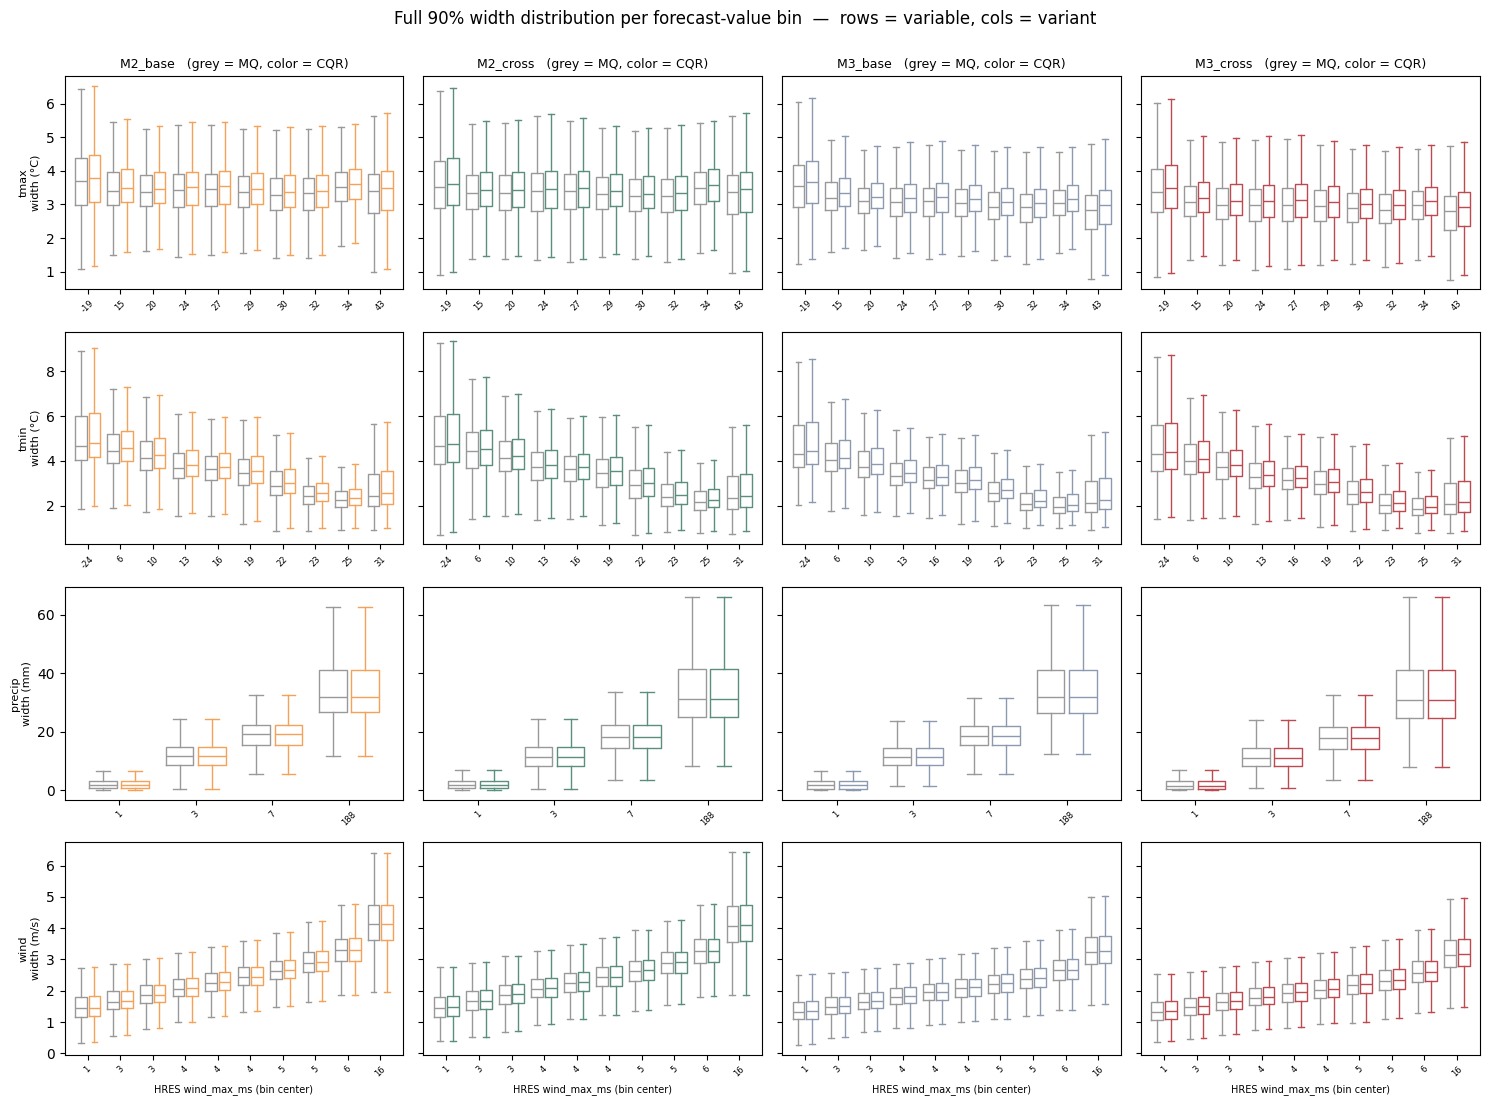

Each pair of boxes = widths in that value bin: grey = MQ as shipped, colored = CQR (grey + 2·Q).
Boxes that grow/shift with the value = adaptivity; compare colored boxes ACROSS columns
to see which variant is sharpest at a given forecast value.


In [21]:
# === 12d. Width DISTRIBUTION vs forecast value — boxplots, grid of variable x variant ===
# Boxes show the spread of the 90% interval width within each equal-count value bin:
# grey = MQ (as shipped), colored = CQR (same band ± Q).
NBINS = 10
fig, axes = plt.subplots(len(VARS), len(VARIANT_NAMES), figsize=(15, 11),
                         sharex='row', sharey='row')
for var_idx, var in enumerate(VARS):
    var_name = var['name']; band = bands_by_var[var_name]; hres_vals = band['hres']
    bin_edges = np.unique(np.quantile(hres_vals, np.linspace(0, 1, NBINS + 1)))   # equal-count value bins
    n_bins = len(bin_edges) - 1
    bin_idx = np.clip(np.digitize(hres_vals, bin_edges[1:-1]), 0, n_bins - 1)
    bin_labels = [f'{0.5*(bin_edges[b]+bin_edges[b+1]):.0f}' for b in range(n_bins)]  # bin-center value
    for variant_idx, variant in enumerate(VARIANT_NAMES):
        ax = axes[var_idx, variant_idx]
        for method, offset, color in (('MQ', -0.21, '#999999'), ('CQR', 0.21, MODEL_COLORS[variant])):
            lower, upper = band['variants'][variant]['methods'][method]
            width = np.clip(upper - lower, 0, None)
            width_by_bin = [width[bin_idx == b] for b in range(n_bins)]
            ax.boxplot(width_by_bin, positions=np.arange(1, n_bins + 1) + offset,
                       showfliers=False, widths=0.36,
                       medianprops=dict(color=color), boxprops=dict(color=color),
                       whiskerprops=dict(color=color), capprops=dict(color=color))
        ax.set_xticks(range(1, n_bins + 1)); ax.set_xticklabels(bin_labels, rotation=45, fontsize=6)
        if var_idx == 0: ax.set_title(f'{variant}   (grey = MQ, color = CQR)', fontsize=9)
        if variant_idx == 0: ax.set_ylabel(f'{var_name}\nwidth ({band["unit"]})', fontsize=8)
        if var_idx == len(VARS) - 1: ax.set_xlabel(f'HRES {var["col"]} (bin center)', fontsize=7)
fig.suptitle('Full 90% width distribution per forecast-value bin  —  rows = variable, cols = variant',
             y=1.0)
plt.tight_layout(); plt.show()
print('Each pair of boxes = widths in that value bin: grey = MQ as shipped, colored = CQR (grey + 2·Q).')
print('Boxes that grow/shift with the value = adaptivity; compare colored boxes ACROSS columns')
print('to see which variant is sharpest at a given forecast value.')


## 11. Gating diagnostic — Q-Q for the cells where M3_base hurts most vs raw

These are exactly the cells §9d's proposed per-cell×var gating
(`per_cell_qn8727_s0.csv`) would switch off first: cells where M3_base's mean
absolute error is *worse* than doing nothing. The Q-Q shape says whether
that's a real distortion worth gating around, or just noise from a handful of
extreme days — the read decides whether shipping goes with per-cell×var
gating, no gating, or holding precip out entirely.

== per-cell M3_base damage (mean ae_M3_base - mean ae_raw): what gating would turn off ==
   var  n_cells  n_damaged  share_damaged  damage_p50  damage_p10  damage_max
  tmax     8727         56          0.006      -0.237      -1.088       0.753
  tmin     8727         19          0.002      -0.213      -0.893       0.284
precip     8727        434          0.050      -0.154      -0.736       1.385
  wind     8727         16          0.002      -0.379      -1.182       0.193


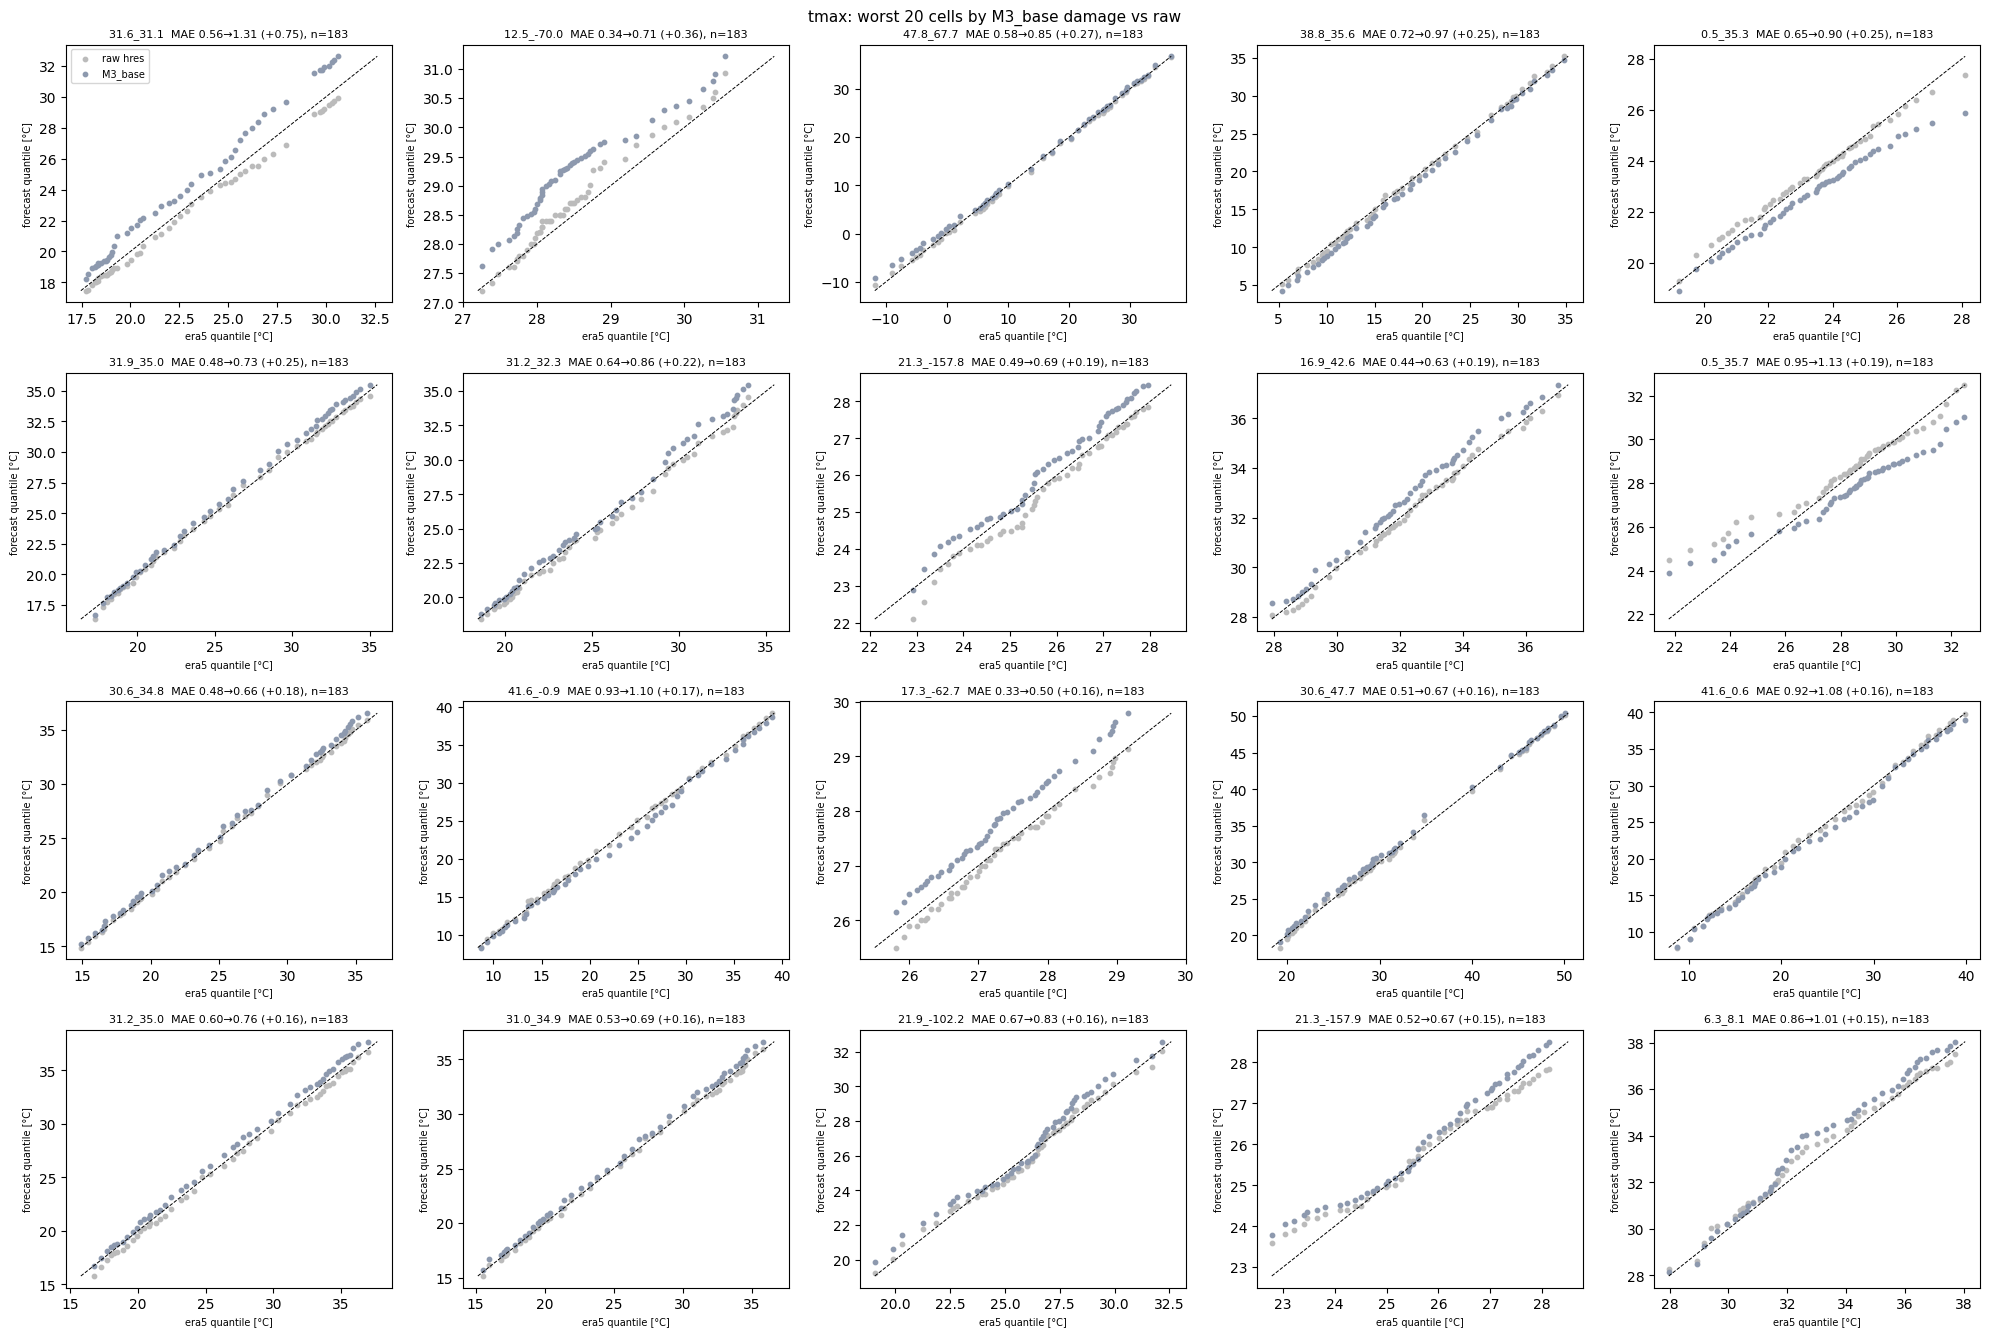

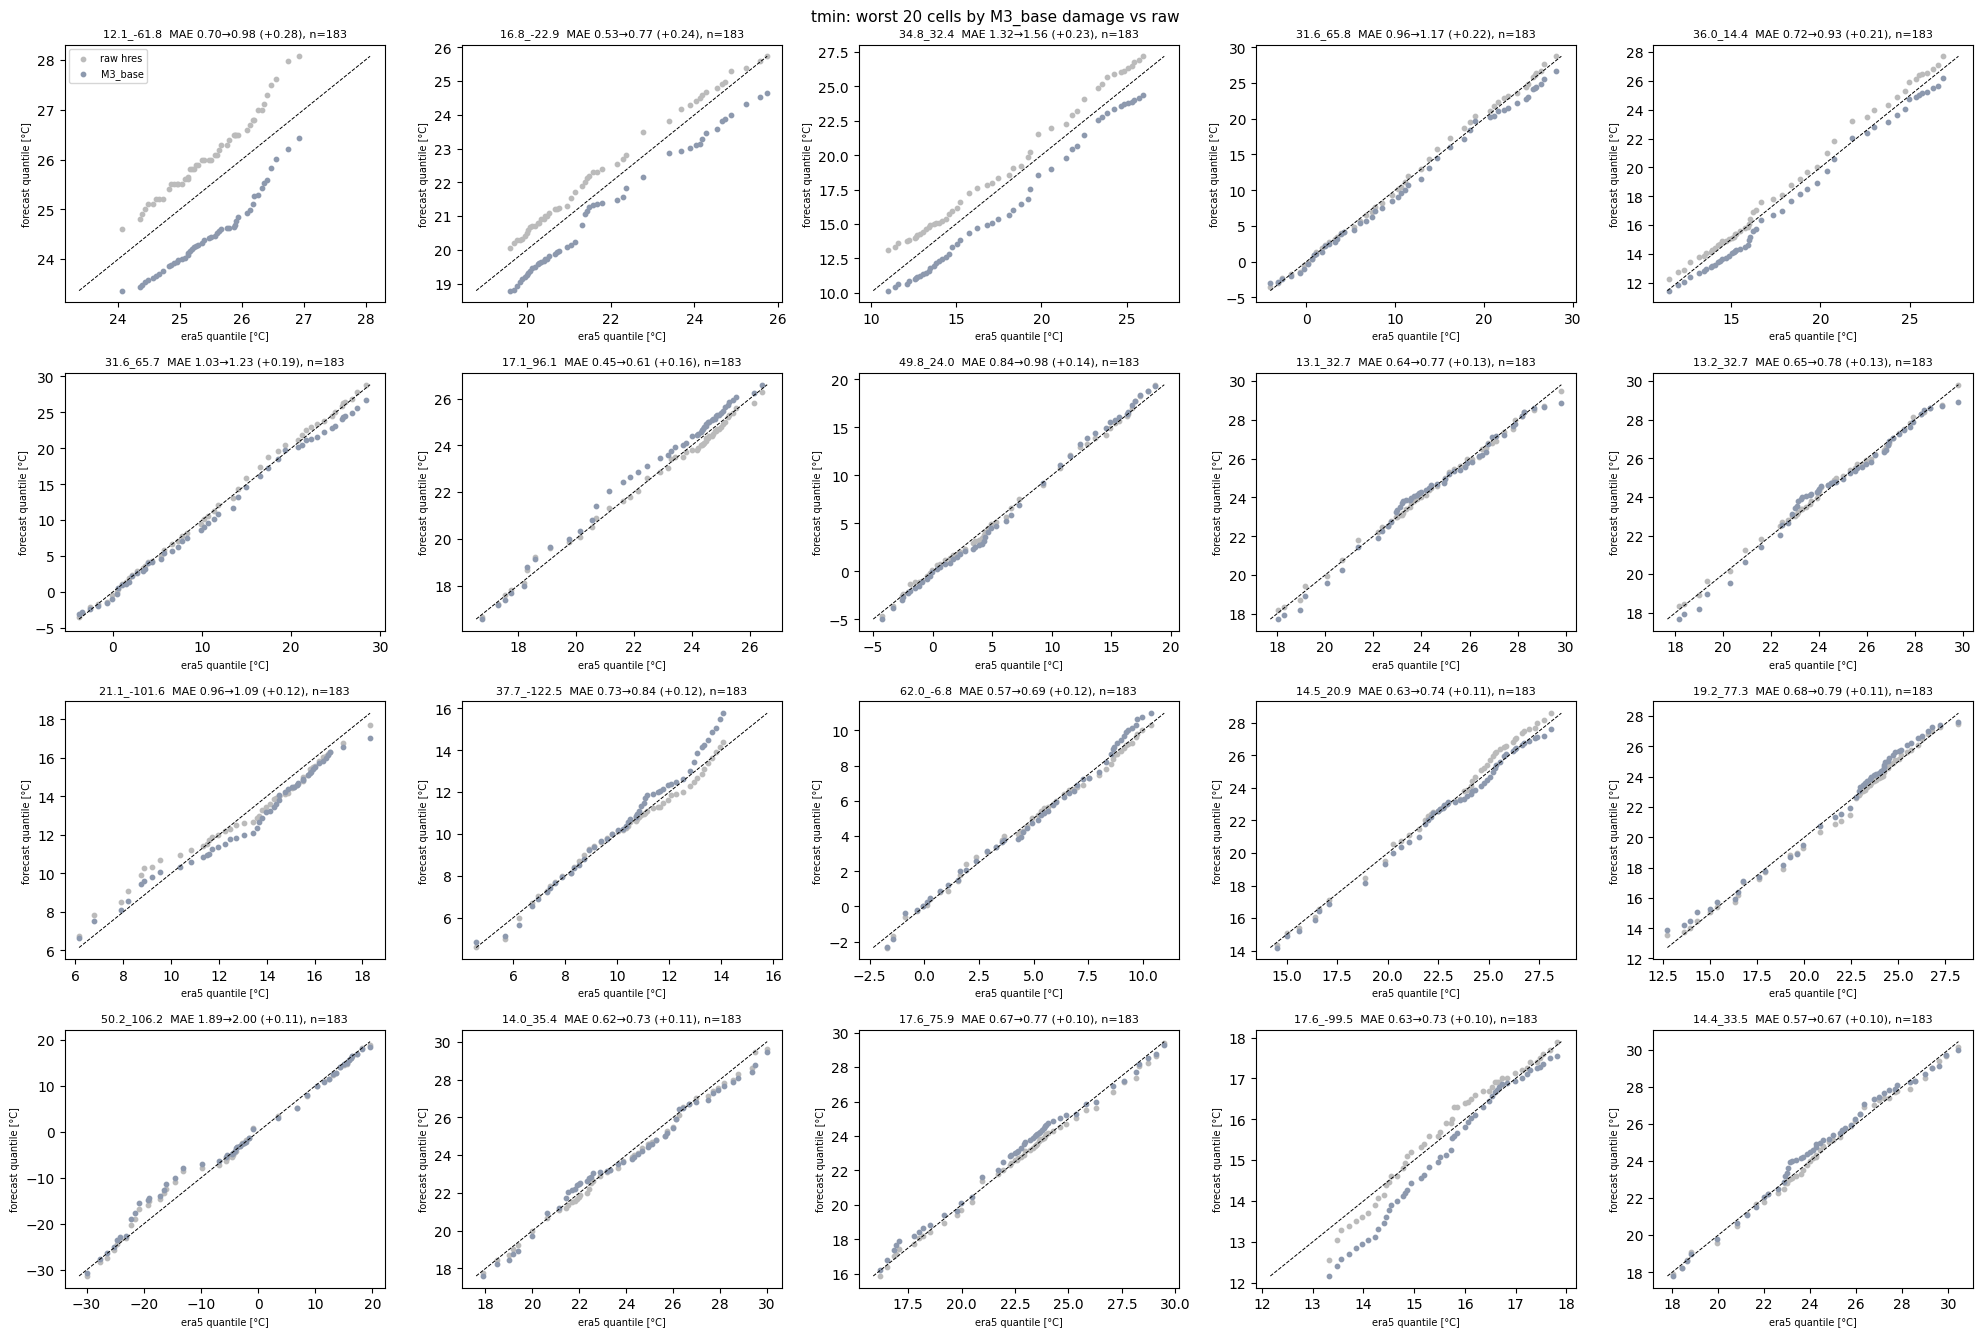

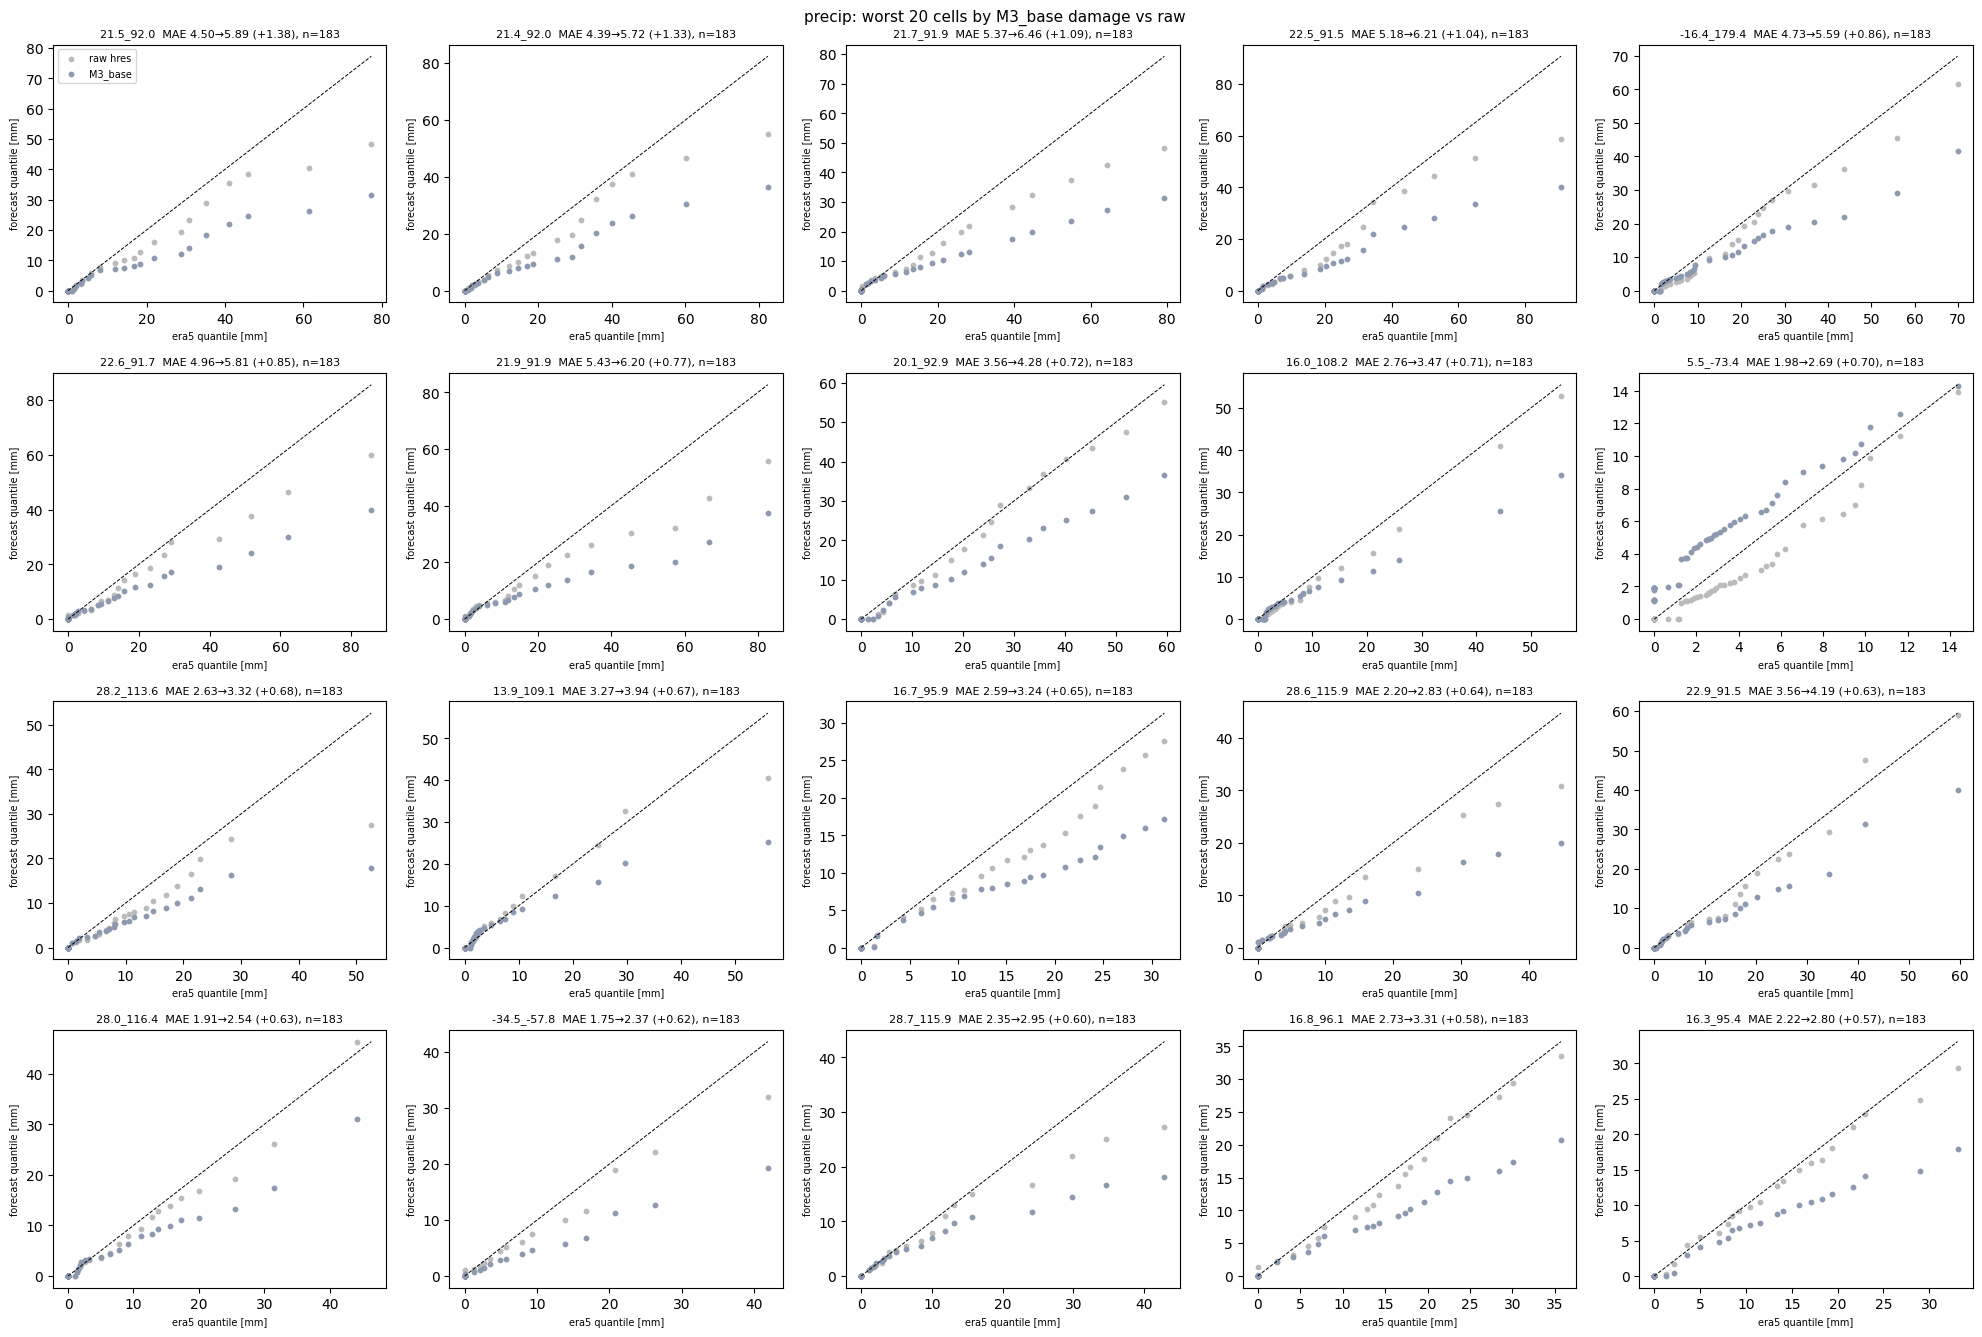

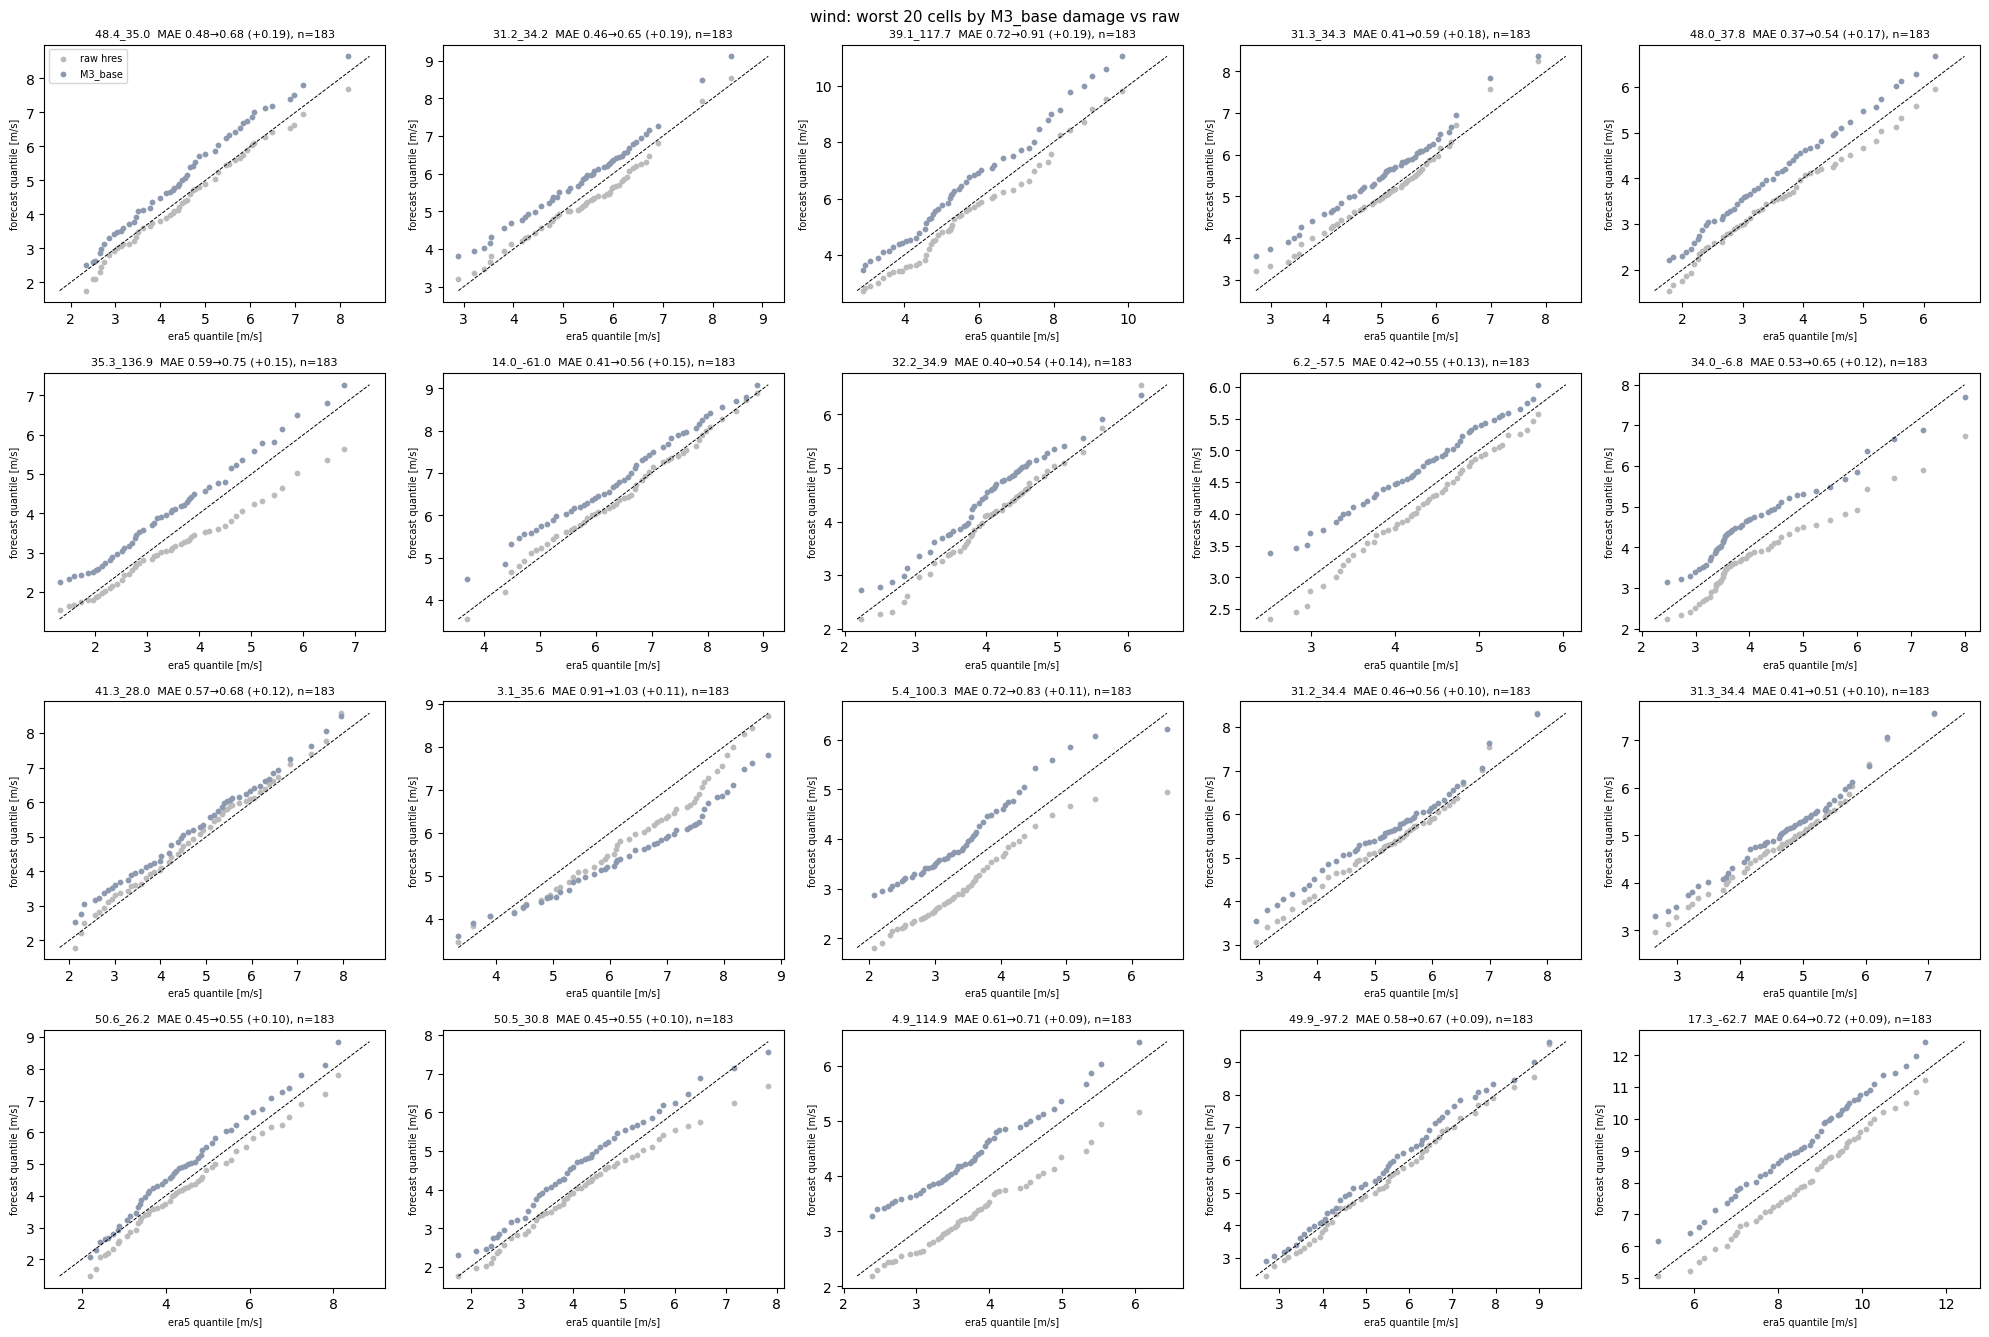

In [25]:
# For each variable, rank cells by how much the M3_base correction HURTS
# relative to doing nothing (mean |err| goes UP, not down). These are exactly
# the cells §9d's proposed per-cell x var gating would switch off first —
# reading their Q-Q shape decides whether that damage is a real distortion
# worth gating around, or a few noisy days. Raw vs M3_base only (no M2/cross
# variants) to keep the decision focused.
quantile_levels = np.linspace(0.02, 0.98, 49)
N_WORST = 20
GRID_ROWS, GRID_COLS = 4, 5

per_cell_by_var, worst_keys_by_var = {}, {}
summary_rows = []
for var in VARS:
    var_name = var['name']
    test = errors_by_var[var_name]
    per_cell_mae = test.groupby('key')[['ae_raw', 'ae_M3_base']].mean()
    per_cell_mae['n_days'] = test.groupby('key').size()
    per_cell_mae['damage'] = per_cell_mae['ae_M3_base'] - per_cell_mae['ae_raw']
    per_cell_mae = per_cell_mae.sort_values('damage', ascending=False)
    per_cell_by_var[var_name] = per_cell_mae
    worst_keys_by_var[var_name] = per_cell_mae.head(N_WORST).index.tolist()

    damaged = per_cell_mae[per_cell_mae['damage'] > 0.1]
    summary_rows.append({
        'var': var_name,
        'n_cells': len(per_cell_mae),
        'n_damaged': len(damaged),
        'share_damaged': len(damaged) / len(per_cell_mae),
        'damage_p50': per_cell_mae['damage'].quantile(0.50),
        'damage_p10': per_cell_mae['damage'].quantile(0.10),
        'damage_max': per_cell_mae['damage'].max(),
    })

print('== per-cell M3_base damage (mean ae_M3_base - mean ae_raw): what gating would turn off ==')
print(pd.DataFrame(summary_rows).round(3).to_string(index=False))

# Q-Q per variable: the worst N_WORST cells by damage, raw vs M3_base only.
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    per_cell_mae = per_cell_by_var[var_name]
    worst_keys = worst_keys_by_var[var_name]

    fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(4*GRID_COLS, 3.4*GRID_ROWS))
    for panel_idx, cell_key in enumerate(worst_keys):
        ax = axes.ravel()[panel_idx]
        cell_rows = test[test.key == cell_key]
        truth_q = cell_rows[era5_col(var_name)].quantile(quantile_levels).to_numpy()
        model_q = {'raw': cell_rows[hres_col(var_name)].quantile(quantile_levels).to_numpy(),
                   'M3_base': cell_rows['M3_base'].quantile(quantile_levels).to_numpy()}
        lo_val = float(min(truth_q.min(), *(q.min() for q in model_q.values())))
        hi_val = float(max(truth_q.max(), *(q.max() for q in model_q.values())))
        ax.plot([lo_val, hi_val], [lo_val, hi_val], 'k--', lw=0.7)
        for model_name, model_quantiles in model_q.items():
            ax.scatter(truth_q, model_quantiles, s=10, color=MODEL_COLORS[model_name],
                       label='raw hres' if model_name == 'raw' else model_name)
        row = per_cell_mae.loc[cell_key]
        ax.set_title(f"{cell_key}  MAE {row['ae_raw']:.2f}→{row['ae_M3_base']:.2f} "
                     f"(+{row['damage']:.2f}), n={int(row['n_days'])}", fontsize=8)
        ax.set_xlabel(f'era5 quantile [{unit}]', fontsize=7)
        ax.set_ylabel(f'forecast quantile [{unit}]', fontsize=7)
        if panel_idx == 0:
            ax.legend(fontsize=7)
    fig.suptitle(f'{var_name}: worst {N_WORST} cells by M3_base damage vs raw', fontsize=11)
    plt.tight_layout()
    plt.show()